In [1]:
import sys
sys.path.insert(0, "/home/nfm/ViT-Prisma/src")

import os
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

from vit_prisma.utils.constants import BASE_DIR, DATA_DIR, MODEL_DIR, DEVICE, MODEL_CHECKPOINTS_DIR
from vit_prisma.utils.tutorial_utils import calculate_clean_accuracy, load_clip_models, plot_image, get_feature_activations
from vit_prisma.utils.data_utils.loader import load_dataset
from vit_prisma.utils.tutorial_utils import plot_act_distribution
from vit_prisma.utils.tutorial_utils import plot_top_imgs_for_features

/home/nfm/prisma/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nfm/prisma/lib/python3.12/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [2]:
DEVICE = 'cuda' # change to cpu if cpu only paradigm
# BATCH_SIZE = 16

# Load model
from vit_prisma.models.model_loader import load_hooked_model

model_name = "open-clip:laion/CLIP-ViT-B-16-laion2B-s34B-b88K"
model = load_hooked_model(model_name)
model.to(DEVICE);

2026-05-20 01:01:57 INFO:root: Model 'open-clip:laion/CLIP-ViT-B-16-laion2B-s34B-b88K' is supported and passes tests.
2026-05-20 01:01:57 INFO:root: model_id download_pretrained_from_hf: laion/CLIP-ViT-B-16-laion2B-s34B-b88K
2026-05-20 01:01:57 DEBUG:urllib3.connectionpool: Starting new HTTPS connection (1): huggingface.co:443


*****Loading model 'open-clip:laion/CLIP-ViT-B-16-laion2B-s34B-b88K' of type 'VISION'


2026-05-20 01:01:57 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /laion/CLIP-ViT-B-16-laion2B-s34B-b88K/resolve/main/open_clip_config.json HTTP/1.1" 307 0
2026-05-20 01:01:57 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /api/resolve-cache/models/laion/CLIP-ViT-B-16-laion2B-s34B-b88K/7288da5a0d6f0b51c4a2b27c624837a9236d0112/open_clip_config.json HTTP/1.1" 200 0
2026-05-20 01:01:58 INFO:root: model_id download_pretrained_from_hf: laion/CLIP-ViT-B-16-laion2B-s34B-b88K
2026-05-20 01:01:58 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /laion/CLIP-ViT-B-16-laion2B-s34B-b88K/resolve/main/open_clip_pytorch_model.bin HTTP/1.1" 302 0
2026-05-20 01:01:59 INFO:root: visual projection shape: torch.Size([768, 512])
2026-05-20 01:02:00 INFO:root: Loaded pretrained model open-clip:laion/CLIP-ViT-B-16-laion2B-s34B-b88K into HookedTransformer


In [6]:
# Put paths here
from vit_prisma.transforms import get_clip_val_transforms
from torchvision import datasets, transforms
import torchvision

def load_imagenet(imagenet_validation_path, model_type="clip", batch_size=16):
    torch.set_grad_enabled(False)


    # Load dataset with CLIP transform
    if model_type == "clip":
        data_transforms = get_clip_val_transforms()
    else:
        data_transforms = transforms.Compose([
        transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    val_data = torchvision.datasets.ImageFolder(imagenet_validation_path, transform=data_transforms)

    # We'll also load a version of the dataset without the CLIP transform so that we can visualize it beautifully
    viz_transforms = torchvision.transforms.Compose(
                    [
                        torchvision.transforms.Resize((224, 224)),
                        torchvision.transforms.ToTensor(),
                    ]
                )
    viz_data = torchvision.datasets.ImageFolder(imagenet_validation_path, transform=viz_transforms)

    # We only want a subset of validation
            
    subset_dataloader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=4)

    # We only want a subset 
    
    return subset_dataloader, val_data, viz_data

# Put your imagenet path here. You can download ImageNet from kaggle.
imagenet_validation_path = '/home/nfm/data_prisma/imagenet_val/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/val'
subset_dataloader, subset_dataset, viz_data = load_imagenet(imagenet_validation_path, model_type="clip", batch_size=256)

In [6]:
# sample_img = subset_dataset[0][0] # Get the first image from the dataset
# # plot_image(sample_img) # Visualize the image
# plot_image(sample_img)
# sample_img.shape, sample_img.min(), sample_img.max(), sample_img.mean(), sample_img.std()
# len(subset_dataloader.dataset), len(viz_data)
# vis_img.shape, vis_img.min(), vis_img.max(), vis_img.mean(), vis_img.std()
# subset_dataset[50][1]

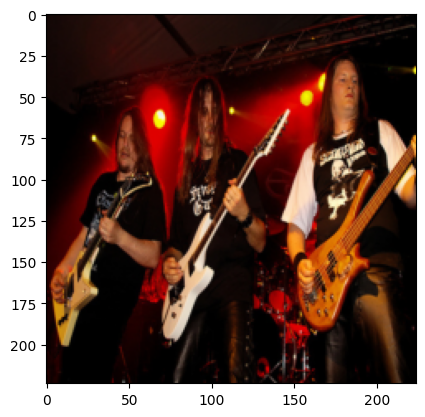

In [20]:
import random
idx = random.randint(0, len(subset_dataset)-1)
sample_img = subset_dataset[idx][0]
vis_img = viz_data[idx][0]
# plot_image(vis_img)
plt.imshow(vis_img.permute(1, 2, 0))
plt.show()
# final_output, cache = model.run_with_cache(sample_img.unsqueeze(0).to(DEVICE)) # Add batch dimension and move to device

In [ ]:
# final_output.shape, cache['hook_post_head_pre_normalize'].shape
# cache.keys()
# final_output - torch.nn.functional.normalize(cache['hook_post_head_pre_normalize'], dim=-1)
# cache['blocks.11.hook_resid_post'].shape
# final_output.shape

torch.Size([1, 512])

In [4]:
# use subset_dataset to save the image embeddings in order
batch_size = 256
img_embeds = torch.zeros((len(subset_dataset), 512))
with torch.no_grad():
    for i in range(0, len(subset_dataset), batch_size):
        batch_imgs = []
        for j in range(i, min(i+batch_size, len(subset_dataset))):
            batch_imgs.append(subset_dataset[j][0])
        batch_imgs = torch.stack(batch_imgs).to(DEVICE)
        final_output, cache  = model.run_with_cache(batch_imgs)
        img_embeds[i:i+batch_size] = final_output.cpu()
        del batch_imgs, final_output, cache
        torch.cuda.empty_cache()

In [7]:
# len(subset_dataset)
batch_size = 256
with torch.no_grad():
    for i in range(0, len(subset_dataset), batch_size):
        # batch_imgs = []
        for j in range(i, min(i+batch_size, len(subset_dataset))):
            # batch_imgs.append(subset_dataset[j][0])
            print(subset_dataset[j][1], end=' ')
            if (j+1) % 50 == 0:
                print()
        break


0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 
1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 
2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 
3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 
4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 
5 5 5 5 5 5 

In [ ]:
pth = "/home/nfm/ViT-Prisma/demos/text_dict.pt"
text_dict = torch.load(pth).to("cpu")

txt_pth = "/home/nfm/clip_text_span/text_descriptions/image_descriptions_general.txt"
with open(txt_pth, "r") as f:
    texts = [line.strip() for line in f.readlines()]
    
# text_dict.shape

# for every row in text_dict, find the top 50 most simmilar images, and save the indices of those images
indices_dict = {}
for i in range(text_dict.shape[0]):
    text_embed = text_dict[i].unsqueeze(0) # Add batch dimension
    # similarities = torch.nn.functional.cosine_similarity(text_embed, img_embeds)
    # simple dot product without normalization
    similarities = img_embeds @ torch.nn.functional.normalize(text_embed, dim=-1).T
    similarities = similarities.squeeze() # Remove batch dimension
    topk = 50
    topk_indices = torch.topk(similarities, k=topk).indices.cpu().numpy()
    indices_dict[i] = topk_indices

In [ ]:
# save indices_dict
# torch.save(indices_dict, "/home/nfm/ViT-Prisma/demos/indices_forclip_dict.pt")

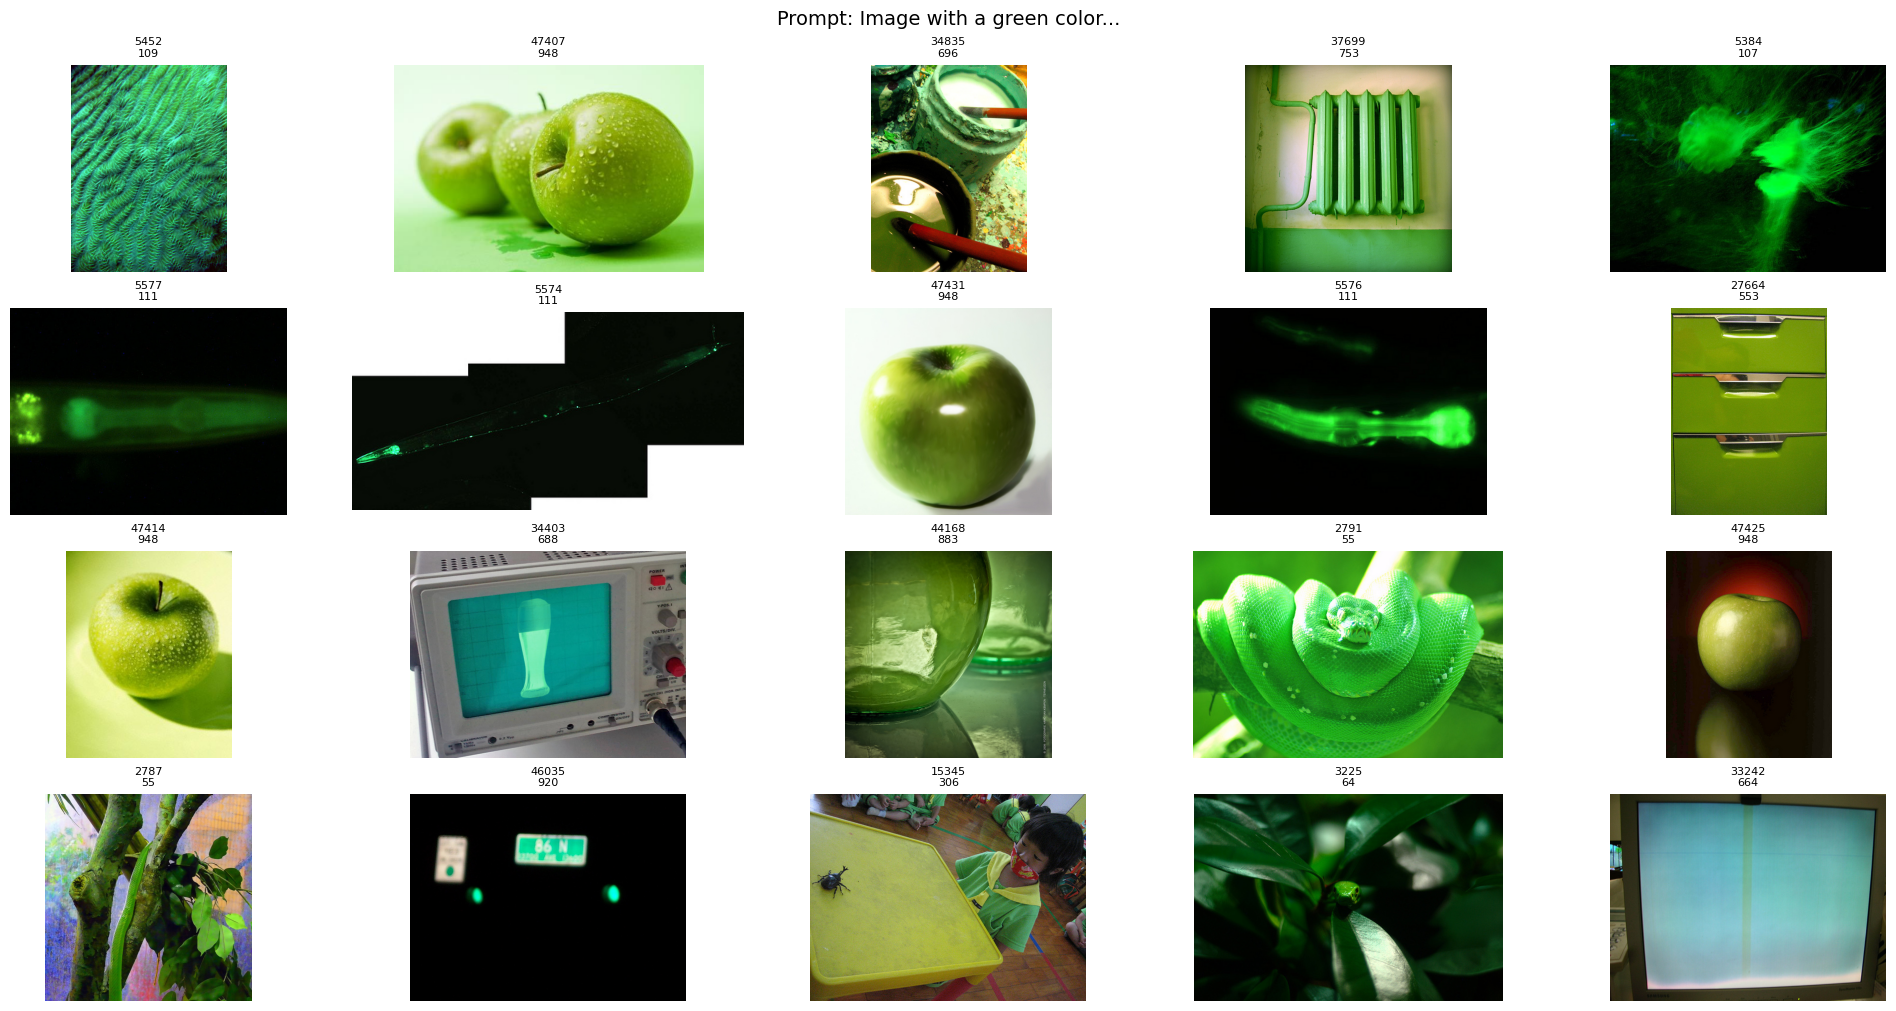

In [9]:
# show top 20 images for a given text prompt
pth = "/home/nfm/ViT-Prisma/demos/text_dict.pt"
text_dict = torch.load(pth).to("cpu")

txt_pth = "/home/nfm/clip_text_span/text_descriptions/image_descriptions_general.txt"
with open(txt_pth, "r") as f:
    texts = [line.strip() for line in f.readlines()]

indices_dict = torch.load("/home/nfm/ViT-Prisma/demos/indices_forclip_dict.pt", weights_only=False)

import random
text_prompt_index = random.randint(0, len(texts) - 1) # Change this to see different prompts

# txt = "A photo with the letter H"
# text_prompt_index = texts.index(txt)
text_prompt_index = 1775
prompt = texts[text_prompt_index]
top_image_indices = indices_dict[text_prompt_index][:20]

fig, axes = plt.subplots(4, 5, figsize=(20, 10), constrained_layout=True)

for i, img_idx in enumerate(top_image_indices):
    img_path, label = subset_dataset.samples[img_idx]
    img = plt.imread(img_path)
    
    ax = axes[i//5, i%5]
    ax.imshow(img)
    ax.set_title(f"{img_idx}\n{label}", fontsize=8)
    ax.axis('off')

plt.suptitle(f"Prompt: {prompt[:50]}...", fontsize=14)
plt.show()


In [18]:
prompt = "a photo of a tench in a water"
token = tokenizer(prompt).to(DEVICE)
with torch.no_grad():
    text_embedding = clip_model.encode_text(token)
    text_embedding = torch.nn.functional.normalize(text_embedding, dim=-1)

# cosine similarity between image and text embedding
similarity = torch.nn.functional.cosine_similarity(final_output, text_embedding)
print(f"Similarity between image and prompt '{prompt}': {similarity.item()}")

NameError: name 'tokenizer' is not defined

Unstandardising image
Top 5 most similar prompts:
Grand cathedral interior (similarity: 0.2691)
ornate cathedral (similarity: 0.2505)
A cathedral (similarity: 0.2386)
Wide-angle perspective (similarity: 0.2174)
Picture taken in a sacred place (similarity: 0.2098)

Using pre-normalization features:
Top 5 most similar prompts:
Grand cathedral interior (similarity: 0.2691)
ornate cathedral (similarity: 0.2505)
A cathedral (similarity: 0.2386)
Wide-angle perspective (similarity: 0.2174)
Picture taken in a sacred place (similarity: 0.2098)


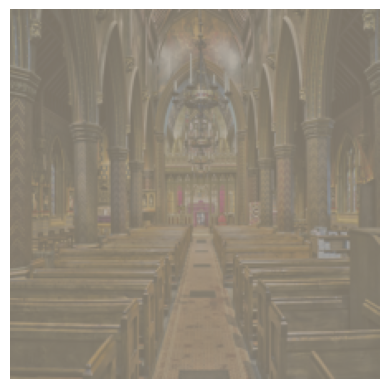

In [34]:
import random
idx = random.randint(0, len(subset_dataset)-1)
sample_img = subset_dataset[idx][0]
vis_img = viz_data[idx][0]
plot_image(vis_img)
final_output, cache = model.run_with_cache(sample_img.unsqueeze(0).to(DEVICE)) # Add batch dimension and move to device

all_text_embs = torch.load("/home/nfm/ViT-Prisma/demos/text_dict.pt")
all_text_embs = all_text_embs.to(DEVICE)
similarities = torch.nn.functional.cosine_similarity(final_output, all_text_embs)
# similarities = torch.nn.functional.cosine_similarity(cache['hook_post_head_pre_normalize'], all_text_embs)
topk = 5
topk_indices = torch.topk(similarities, k=topk).indices
print(f"Top {topk} most similar prompts:")
for idx in topk_indices:
    print(f"{texts[idx]} (similarity: {similarities[idx].item():.4f})")

print("\nUsing pre-normalization features:")
# similarities = torch.nn.functional.cosine_similarity(cache['hook_post_head_pre_normalize'], all_text_embs)
# simple dot product without normalization
# similarities = all_text_embs @ cache['hook_post_head_pre_normalize'].T
similarities = all_text_embs @ torch.nn.functional.normalize(cache['hook_post_head_pre_normalize'], dim=-1).T
# similarities = all_text_embs @ cache['blocks.11.hook_resid_post'].T
similarities = similarities.squeeze() # Remove batch dimension
topk = 5
topk_indices = torch.topk(similarities, k=topk).indices
print(f"Top {topk} most similar prompts:")
for idx in topk_indices:
    print(f"{texts[idx]} (similarity: {similarities[idx].item():.4f})")

In [ ]:
# texts[:10]

imagenet_texts = [f"an image of {idx_to_name[i]}" for i in range(1000)]

['an image of tench',
 'an image of goldfish',
 'an image of great_white_shark',
 'an image of tiger_shark',
 'an image of hammerhead',
 'an image of electric_ray',
 'an image of stingray',
 'an image of cock',
 'an image of hen',
 'an image of ostrich']

In [ ]:
import open_clip
import torch

imagenet_texts = [f"an image of {idx_to_name[i]}" for i in range(1000)]

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load the exact same CLIP model (Text Encoder)
clip_model, _, _ = open_clip.create_model_and_transforms('ViT-B-16', pretrained='laion2b_s34b_b88k')
clip_model = clip_model.to(DEVICE).eval()
tokenizer = open_clip.get_tokenizer('ViT-B-16')

# txt_pth = "/home/nfm/clip_text_span/text_descriptions/image_descriptions_general.txt"
# with open(txt_pth, "r") as f:
#     texts = [line.strip() for line in f.readlines()]

text_tokens = tokenizer(imagenet_texts).to(DEVICE)

with torch.no_grad():
    # Get text embeddings and L2 normalize them
    text_embeddings = clip_model.encode_text(text_tokens)
    text_embeddings = torch.nn.functional.normalize(text_embeddings, dim=-1)

# # Shape: [3000, 512]
# print(text_embeddings.shape)
save_path = "/home/nfm/ViT-Prisma/demos/text_dict_imagenet.pt"
torch.save(text_embeddings.cpu(), save_path)

KeyboardInterrupt: 

In [ ]:
# imgnet_embds = torch.load("/home/nfm/ViT-Prisma/demos/text_dict.pt")
# imgnet_embds.shape

In [1]:
import sys
sys.path.insert(0, "/home/nfm/ViT-Prisma/src")

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import vit_prisma
from vit_prisma.utils.data_utils.imagenet.imagenet_dict import IMAGENET_DICT
from vit_prisma.utils import prisma_utils

import numpy as np
import torch
from fancy_einsum import einsum
from collections import defaultdict

import plotly.graph_objs as go
import plotly.express as px

import matplotlib.colors as mcolors

from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

from IPython.core.display import display, HTML


# Helper function (ignore)
def plot_image(image):
  plt.figure()
  plt.axis('off')
  plt.imshow(image.permute(1,2,0))

class ConvertTo3Channels:
    def __call__(self, img):
        if img.mode != 'RGB':
            return img.convert('RGB')
        return img

transform = transforms.Compose([
    ConvertTo3Channels(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

def plot_logit_boxplot(average_logits, labels):
  hovertexts = np.array([[IMAGENET_DICT[i] for _ in range(25)] for i in range(1000)])

  fig = go.Figure()
  data = []

  # if tensor, turn to numpy
  if isinstance(average_logits, torch.Tensor):
      average_logits = average_logits.detach().cpu().numpy()

  for i in range(average_logits.shape[1]):  # For each layer
      layer_logits = average_logits[:, i]
      hovertext = hovertexts[:, i]
      box = fig.add_trace(go.Box(
          y=layer_logits,
          name=f'{layer_labels[i]}',
          text=hovertext,
          hoverinfo='y+text',
          boxpoints='suspectedoutliers'
      ))
      data.append(box)


  means = np.mean(average_logits, axis=0)
  fig.add_trace(go.Scatter(
      x = layer_labels,
      y=means,
      mode='markers',
      name='Mean',
      # line=dict(color='gray'),
      marker=dict(size=4, color='red'),
  ))


  fig.update_layout(
      title='Raw Logit Values Per Layer (each dot is 1 ImageNet Class)',
      xaxis=dict(title='Layer'),
      yaxis=dict(title='Logit Values'),
      showlegend=False
  )

  fig.show()


def plot_patched_component(patched_head, title=''):
  """
  Use for plotting Activation Patching.
  """

  fig = go.Figure(data=go.Heatmap(
      z=patched_head.detach().numpy(),
      colorscale='RdBu',  # You can choose any colorscale
      colorbar=dict(title='Value'),  # Customize the color bar
      hoverongaps=False
  ))
  fig.update_layout(
      title=title,
      xaxis_title='Attention Head',
      yaxis_title='Patch Number',
  )

  return fig

def imshow(tensor, **kwargs):
    """
    Use for Activation Patching.
    """
    px.imshow(
          prisma_utils.to_numpy(tensor),
          color_continuous_midpoint=0.0,
          color_continuous_scale="RdBu",
          **kwargs,
      ).show()


/home/nfm/prisma/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nfm/prisma/lib/python3.12/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.


/tmp/ipykernel_33319/3807753522.py:25: DeprecationWarning:

Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display



In [2]:
from vit_prisma.models.base_vit import HookedViT

# model_name = "hf_hub:natihash/vit_base_patch16_clip_224.laion2b_linear_probe_real"
# model_name = "vit_base_patch16_224"
# model_name = "vit_base_patch16_clip_224.laion2b_ft_in1k"
# model_name = "hf_hub:natihash/vit_base_patch16_clip_224.laion2b_fullft"
model_name = "open-clip:laion/CLIP-ViT-B-16-laion2B-s34B-b88K"
model = HookedViT.from_pretrained(model_name,
                                        center_writing_weights=True,
                                        center_unembed=True,
                                        fold_ln=True,
                                        refactor_factored_attn_matrices=True,
                                        device="cuda"
                                    )

model = model.to("cuda:0")
model.cfg.device = "cuda:0"
print("Model device config:", model.cfg.device)
print("Is CUDA available?:", torch.cuda.is_available())

2026-05-26 00:45:57 INFO:root: Model 'open-clip:laion/CLIP-ViT-B-16-laion2B-s34B-b88K' is supported and passes tests.
2026-05-26 00:45:57 INFO:root: model_id download_pretrained_from_hf: laion/CLIP-ViT-B-16-laion2B-s34B-b88K
2026-05-26 00:45:57 DEBUG:urllib3.connectionpool: Starting new HTTPS connection (1): huggingface.co:443


*****Loading model 'open-clip:laion/CLIP-ViT-B-16-laion2B-s34B-b88K' of type 'VISION'


2026-05-26 00:45:57 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /laion/CLIP-ViT-B-16-laion2B-s34B-b88K/resolve/main/open_clip_config.json HTTP/1.1" 307 0
2026-05-26 00:45:57 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /api/resolve-cache/models/laion/CLIP-ViT-B-16-laion2B-s34B-b88K/7288da5a0d6f0b51c4a2b27c624837a9236d0112/open_clip_config.json HTTP/1.1" 200 0
2026-05-26 00:45:58 INFO:root: model_id download_pretrained_from_hf: laion/CLIP-ViT-B-16-laion2B-s34B-b88K
2026-05-26 00:45:58 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /laion/CLIP-ViT-B-16-laion2B-s34B-b88K/resolve/main/open_clip_pytorch_model.bin HTTP/1.1" 302 0
2026-05-26 00:45:59 INFO:root: visual projection shape: torch.Size([768, 512])


LayerNorm folded.
Centered weights writing to residual stream


2026-05-26 00:46:05 INFO:root: Loaded pretrained model open-clip:laion/CLIP-ViT-B-16-laion2B-s34B-b88K into HookedTransformer


Model device config: cuda:0
Is CUDA available?: True


In [3]:
import json
LOCAL_JSON_PATH = "/home/nfm/ViT-Prisma/demos/imagenet_class_index.json"
with open(LOCAL_JSON_PATH, 'r') as f:
    imagenet_class_index = json.load(f)

wnid_to_name = {}
for idx, (wnid, class_name) in imagenet_class_index.items():
    safe_class_name = class_name.replace(" ", "_").replace("/", "_").replace(",", "")
    wnid_to_name[wnid] = safe_class_name

wnid_to_idx = {wnid: int(idx) for idx, (wnid, name) in imagenet_class_index.items()}
idx_to_name = {int(idx): name for idx, (wnid, name) in imagenet_class_index.items()}

idx_to_wnid = {int(idx): wnid for idx, (wnid, name) in imagenet_class_index.items()}
name_to_idx = {name: int(idx) for idx, (wnid, name) in imagenet_class_index.items()}

### Attribution Patching

In [ ]:
import os
import json
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from vit_prisma.transforms import get_clip_val_transforms

text_embeddings = torch.load("/home/nfm/ViT-Prisma/demos/text_dict.pt").to(model.cfg.device)
txts_pth = "/home/nfm/clip_text_span/text_descriptions/image_descriptions_general.txt"
with open(txts_pth, "r") as f:
    texts = [line.strip() for line in f.readlines()]

clip_class_inds = torch.load("/home/nfm/ViT-Prisma/demos/indices_forclip_dict.pt", weights_only=False)

IMAGENET_VAL_DIR = '/home/nfm/data_prisma/imagenet_val/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/val/'

mytransform = get_clip_val_transforms()
# Single image, single head, all texts
dataset = ImageFolder(IMAGENET_VAL_DIR, transform=mytransform) 

2026-05-20 16:25:35 WARNING:matplotlib.image: Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7520971..2.1316772].


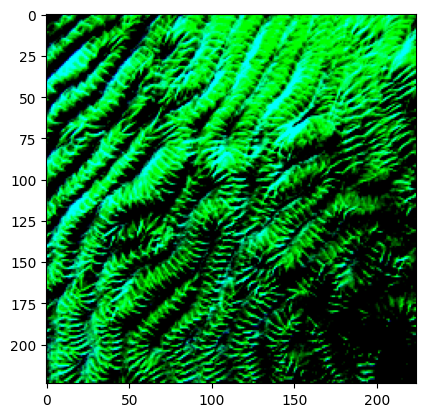

In [47]:
txt = "A photo with motion blur"
txt = "A photo with the letter A"
txt = "Image with a green color"

txt_idx = texts.index(txt)
batch_inds = clip_class_inds[txt_idx][:2]
batch_imgs = []
for j in batch_inds:
    img_path, label = dataset.samples[j]
    img = Image.open(img_path).convert('RGB')
    img_tensor = mytransform(img)
    batch_imgs.append(img_tensor)
batch_imgs = torch.stack(batch_imgs).to(model.cfg.device)

plt.imshow(batch_imgs[0].permute(1, 2, 0).cpu())

In [48]:
head_idx = 11
layer_idx = 10

activation = {}

def save_hook(tensor, hook):
    activation["z"] = tensor  # live tensor, not detached
    return tensor

hook_name = f"blocks.{layer_idx}.attn.hook_z"

final_outputs = model.run_with_hooks(
    batch_imgs,
    fwd_hooks=[(hook_name, save_hook)]
)

z = activation["z"][:, 0, head_idx, :]
print(z.requires_grad)  # should be True

t = text_embeddings[txt_idx]   # (512,)

scores = final_outputs @ t      # (B,)

print(z.requires_grad)
print(z.grad_fn)
print(final_outputs.requires_grad)

test = torch.autograd.grad(
    outputs=final_outputs.sum(),
    inputs=z,
    allow_unused=True,
)[0]

print(test is None)

saved = {}

def capture_hook(tensor, hook):
    tensor.retain_grad()

    # save exact tensor used downstream
    saved["full_z"] = tensor

    return tensor

hook_name = f"blocks.{layer_idx}.attn.hook_z"

final_outputs = model.run_with_hooks(
    batch_imgs,
    fwd_hooks=[(hook_name, capture_hook)],
)

full_z = saved["full_z"]
head_z = full_z[:, 0, head_idx, :]

t = text_embeddings[txt_idx]

scores = final_outputs @ t

loss = scores.sum()
loss.backward(retain_graph=True)

grads = full_z.grad[:, 0, head_idx, :]

print(grads.shape)

_, clean_cache = model.run_with_cache(batch_imgs)

# create just just single color gray image(not averaging batch, just one image of all gray pixels)
gray_imgs = make_gray_corrupted_image(batch_imgs, device=model.cfg.device) 
_, corrupted_cache = model.run_with_cache(gray_imgs)


clean_z = clean_cache[f"blocks.{layer_idx}.attn.hook_z"][:, 0, head_idx, :]
corrupted_z = corrupted_cache[f"blocks.{layer_idx}.attn.hook_z"][:, 0, head_idx, :]

delta_z = clean_z - corrupted_z

# compute the dot products between the gradients and the delta_z for each image in the batch
attributions = (grads * delta_z).sum(dim=-1)  # (B,)
attributions.shape, attributions

True
True
True
True
torch.Size([2, 64])


(torch.Size([2]), tensor([0.0003, 0.0022], device='cuda:0'))

In [11]:
import torch
import torch.nn.functional as F
from torch.autograd.functional import jvp
from tqdm.auto import tqdm


def make_gray_corrupted_image(reference_img, device,
                               clip_mean=(0.48145466, 0.4578275, 0.40821073),
                               clip_std=(0.26862954, 0.26130258, 0.27577711)):
    """
    A uniform gray image (pixel=0.5) expressed in CLIP-normalized space.
    Pass reference_img just to inherit shape/dtype.
    """
    mean = torch.tensor(clip_mean, device=device).view(1, 3, 1, 1)
    std  = torch.tensor(clip_std,  device=device).view(1, 3, 1, 1)
    return (0.5 * torch.ones_like(reference_img) - mean) / std


def _head_idx_to_layer_head(head_idx, n_heads, n_layers, layers_to_keep):
    """Maps flat 0..(layers_to_keep*n_heads-1) → (layer_idx, head_in_layer)."""
    layer_offset  = n_layers - layers_to_keep
    layer_idx     = layer_offset + (head_idx // n_heads)
    head_in_layer = head_idx % n_heads
    return layer_idx, head_in_layer


def _get_head_activation(model, img, hook_name, head_in_layer):
    """
    Forward pass → returns the CLS-token hook_result for one head. [d_model]
    hook_result shape: [batch, seq, n_heads, d_model]
    """
    with torch.no_grad():
        _, cache = model.run_with_cache(img)
        h = cache[hook_name][0, 0, head_in_layer, :].clone()   # [d_model]
    del cache
    torch.cuda.empty_cache()
    return h


# ──────────────────────────────────────────────
#  Core: single image × all texts × one head
# ──────────────────────────────────────────────

def attribution_scores_for_head(
    model,
    clean_img,           # [1, C, H, W] on device, CLIP-normalised
    text_embeddings,     # [N_texts, d_model] on device
    head_idx,            # flat 0..(LAYERS_TO_KEEP*n_heads - 1)
    corrupted_img=None,  # if None → auto gray image
    h_corr_cache=None,   # pre-computed h_corr to skip the corrupted pass
    LAYERS_TO_KEEP=4,
    eps=1e-8,
):
    """
    Attribution patching for *one head* and *all texts* from a single image.

    Returns
    -------
    attribution_scores : [N_texts]  – positive ↔ head promotes that text's similarity
    cosine_sims        : [N_texts]  – raw cos-sim between clean output and each text
    """
    device  = model.cfg.device
    n_heads = model.cfg.n_heads     # 12 for ViT-B
    n_layers= model.cfg.n_layers    # 12 for ViT-B
    d_model = model.cfg.d_model     # 768 for ViT-B

    layer_idx, head_in_layer = _head_idx_to_layer_head(
        head_idx, n_heads, n_layers, LAYERS_TO_KEEP
    )
    hook_name = f'blocks.{layer_idx}.attn.hook_result'
    # hook_result: [batch, seq_len, n_heads, d_model]

    # ── Corrupted activation (can be precomputed and reused across images) ──
    if h_corr_cache is not None:
        h_corr = h_corr_cache
    else:
        if corrupted_img is None:
            corrupted_img = make_gray_corrupted_image(clean_img, device)
        h_corr = _get_head_activation(model, corrupted_img, hook_name, head_in_layer)

    # ── Clean activation ──
    h_clean = _get_head_activation(model, clean_img, hook_name, head_in_layer)

    # Δh: the "direction" we're patching in
    delta = h_corr - h_clean   # [d_model]

    # ── JVP: how does final_output shift when the head is nudged by delta? ──
    #
    # We want J·δ where J = ∂final_output / ∂h_act  (evaluated at clean).
    # torch.autograd.functional.jvp computes this exactly via forward-mode AD.
    #
    # model_with_head_perturbation(p) ≡ model output when h_act ← h_act + p
    # JVP at p=0 with tangent δ gives us  (output_clean, J·δ).

    def model_with_head_perturbation(perturbation):
        def patch_hook(value, hook):
            # value: [batch, seq, n_heads, d_model]
            patched = value.clone()
            patched[0, 0, head_in_layer, :] = (
                patched[0, 0, head_in_layer, :] + perturbation
            )
            return patched

        out = model.run_with_hooks(
            clean_img,
            fwd_hooks=[(hook_name, patch_hook)],
        )
        # out: [1, d_model]  →  [d_model]
        return out[0]

    zero = torch.zeros(d_model, device=device)

    # final_output : [d_model]  (clean CLS embedding)
    # Jv           : [d_model]  (how output moves when head is nudged by delta)
    final_output, Jv = jvp(
        model_with_head_perturbation,
        (zero,),
        (delta,),
    )

    # ── Attribution for all texts (analytic cosine-sim gradient, one matmul) ──
    #
    # attr_t = c_t · Jv
    # c_t    = ∂cosine_sim(final_output, text_t) / ∂final_output
    #        = (text_norm_t − a_norm · sim_t) / ‖a‖
    #
    # Stacked for all texts: C [N,d] @ Jv [d] → [N]  — one shot, no loops.

    a      = final_output.detach()              # [d_model]
    a_mag  = a.norm().clamp(min=eps)
    a_norm = a / a_mag                          # [d_model]

    B_norm   = F.normalize(text_embeddings.float(), dim=-1)        # [N, d_model]
    cos_sims = (a_norm * B_norm).sum(dim=1)                        # [N]

    # Gradient of cosine_sim(a, b_t) w.r.t. a  →  [N, d_model]
    c_t = (B_norm - cos_sims.unsqueeze(1) * a_norm.unsqueeze(0)) / a_mag

    # Attribution scores: [N]
    attribution_scores = (c_t * Jv.detach().unsqueeze(0)).sum(dim=1)

    return attribution_scores, cos_sims.detach()


# ──────────────────────────────────────────────
#  Outer loop: full dataset × all texts × one head
# ──────────────────────────────────────────────

def compute_all_attributions(
    model,
    dataloader,          # batched dataloader (shuffle=False)
    text_embeddings,     # [N_texts, d_model]
    head_idx,
    LAYERS_TO_KEEP=4,
    save_path=None,      # optional path to save incrementally
):
    """
    Runs attribution patching for every image in the dataloader.

    Returns
    -------
    all_attrs  : [N_images, N_texts]
    all_sims   : [N_images, N_texts]
    """
    device  = model.cfg.device
    n_heads = model.cfg.n_heads
    n_layers= model.cfg.n_layers

    layer_idx, head_in_layer = _head_idx_to_layer_head(
        head_idx, n_heads, n_layers, LAYERS_TO_KEEP
    )
    hook_name = f'blocks.{layer_idx}.attn.hook_result'

    # ── Compute corrupted activation ONCE (gray image is always the same) ──
    sample_img   = next(iter(dataloader))[0][:1].to(device)
    corrupted_img = make_gray_corrupted_image(sample_img, device)
    h_corr = _get_head_activation(model, corrupted_img, hook_name, head_in_layer)
    print(f"Head {head_idx:2d}  →  layer {layer_idx}, head-in-layer {head_in_layer}")
    print(f"||h_corr - h_clean|| will vary per image; h_corr precomputed.")

    all_attrs, all_sims = [], []

    for batch_imgs, batch_labels in tqdm(dataloader, desc=f"Head {head_idx}"):
        batch_size = batch_imgs.shape[0]
        batch_attrs, batch_sims = [], []

        for i in range(batch_size):
            img = batch_imgs[i : i + 1].to(device)

            attr, sims = attribution_scores_for_head(
                model,
                clean_img       = img,
                text_embeddings = text_embeddings,
                head_idx        = head_idx,
                h_corr_cache    = h_corr,   # reuse — no extra forward pass
                LAYERS_TO_KEEP  = LAYERS_TO_KEEP,
            )
            batch_attrs.append(attr)
            batch_sims.append(sims)

        all_attrs.append(torch.stack(batch_attrs))   # [B, N_texts]
        all_sims.append(torch.stack(batch_sims))

    all_attrs = torch.cat(all_attrs, dim=0)   # [N_images, N_texts]
    all_sims  = torch.cat(all_sims,  dim=0)

    if save_path:
        torch.save({'attributions': all_attrs.cpu(),
                    'cosine_sims':  all_sims.cpu(),
                    'head_idx':     head_idx}, save_path)
        print(f"Saved → {save_path}")

    return all_attrs, all_sims

In [5]:
import torch
import torch.nn.functional as F
from torch.autograd.functional import jvp
from tqdm.auto import tqdm


# ──────────────────────────────────────────────────────────────
#  Helpers
# ──────────────────────────────────────────────────────────────

def make_gray_corrupted_image(reference_img, device,
                               clip_mean=(0.48145466, 0.4578275, 0.40821073),
                               clip_std =(0.26862954, 0.26130258, 0.27577711)):
    """Uniform gray (pixel=0.5) expressed in CLIP-normalized space."""
    mean = torch.tensor(clip_mean, device=device).view(1, 3, 1, 1)
    std  = torch.tensor(clip_std,  device=device).view(1, 3, 1, 1)
    return (0.5 * torch.ones_like(reference_img) - mean) / std


def _head_idx_to_layer_head(head_idx, n_heads, n_layers, layers_to_keep):
    layer_offset  = n_layers - layers_to_keep
    layer_idx     = layer_offset + (head_idx // n_heads)
    head_in_layer = head_idx % n_heads
    return layer_idx, head_in_layer


def _get_z_activation(model, img, hook_name, head_in_layer):
    """
    Single forward pass → CLS-token hook_z for one head.
    hook_z shape: [batch, seq_len, n_heads, d_head]
    Returns: [d_head]
    """
    with torch.no_grad():
        _, cache = model.run_with_cache(img)
        # position 0 = CLS token
        z = cache[hook_name][0, 0, head_in_layer, :].clone()   # [d_head]
    del cache
    torch.cuda.empty_cache()
    return z


# ──────────────────────────────────────────────────────────────
#  Core: single image × all texts × one head
# ──────────────────────────────────────────────────────────────

def attribution_scores_for_head(
    model,
    clean_img,           # [1, C, H, W] on device, CLIP-normalised
    text_embeddings,     # [N_texts, d_model] on device
    head_idx,            # flat 0..(LAYERS_TO_KEEP*n_heads - 1)
    corrupted_img=None,
    z_corr_cache=None,   # precomputed z_corr to skip the corrupted forward pass
    LAYERS_TO_KEEP=4,
    eps=1e-8,
):
    """
    Attribution patching for one head, all texts, one image.

    Hook used: blocks.{layer}.attn.hook_z  (shape [batch, seq, n_heads, d_head])
    Delta lives in d_head space (64-dim for ViT-B).
    The W_O projection and everything downstream is handled by the JVP.

    Returns
    -------
    attribution_scores : [N_texts]
    cosine_sims        : [N_texts]
    """
    device  = model.cfg.device
    n_heads = model.cfg.n_heads      # 12
    n_layers= model.cfg.n_layers     # 12
    d_head  = model.cfg.d_head       # 64 for ViT-B

    layer_idx, head_in_layer = _head_idx_to_layer_head(
        head_idx, n_heads, n_layers, LAYERS_TO_KEEP
    )
    # This key IS present in the cache (confirmed from your cache.keys() output)
    hook_name = f'blocks.{layer_idx}.attn.hook_z'

    # ── Corrupted z (can be precomputed once for the whole dataset) ──
    if z_corr_cache is not None:
        z_corr = z_corr_cache
    else:
        if corrupted_img is None:
            corrupted_img = make_gray_corrupted_image(clean_img, device)
        z_corr = _get_z_activation(model, corrupted_img, hook_name, head_in_layer)

    # ── Clean z ──
    z_clean = _get_z_activation(model, clean_img, hook_name, head_in_layer)

    # Δz in d_head space — small (64-dim) and efficient
    delta_z = z_corr - z_clean   # [d_head]

    # ── JVP: how does final_output shift when this head's z is nudged by delta_z? ──
    #
    # model_with_z_perturbation(p) adds p to hook_z[0, 0, head_in_layer, :] and
    # lets z @ W_O (and everything after) propagate normally.
    # jvp at p=0 with tangent delta_z gives (output_clean, J·delta_z).

    def model_with_z_perturbation(perturbation):
        def patch_hook(value, hook):
            # value: [batch, seq_len, n_heads, d_head]
            patched = value.clone()
            patched[0, 0, head_in_layer, :] = (
                patched[0, 0, head_in_layer, :] + perturbation
            )
            return patched

        out = model.run_with_hooks(
            clean_img,
            fwd_hooks=[(hook_name, patch_hook)],
        )
        return out[0]   # [d_model]  (CLS token final output)

    zero_z = torch.zeros(d_head, device=device)

    # final_output : [d_model]  clean CLS embedding
    # Jv           : [d_model]  how output shifts due to delta_z through W_O + rest
    final_output, Jv = jvp(
        model_with_z_perturbation,
        (zero_z,),
        (delta_z,),
    )

    # ── Attribution for all texts — one matmul, no backward loops ──
    #
    # attr_t = c_t · Jv
    # c_t    = ∂cosine_sim(final_output, text_t) / ∂final_output
    #        = (text_norm_t - a_norm * sim_t) / ‖a‖

    a      = final_output.detach()
    a_mag  = a.norm().clamp(min=eps)
    a_norm = a / a_mag

    B_norm   = F.normalize(text_embeddings.float(), dim=-1)         # [N, d_model]
    cos_sims = (a_norm * B_norm).sum(dim=1)                         # [N]

    c_t = (B_norm - cos_sims.unsqueeze(1) * a_norm.unsqueeze(0)) / a_mag  # [N, d_model]

    attribution_scores = (c_t * Jv.detach().unsqueeze(0)).sum(dim=1)  # [N]

    return attribution_scores, cos_sims.detach()


# ──────────────────────────────────────────────────────────────
#  Outer loop: full dataset × all texts × one head
# ──────────────────────────────────────────────────────────────

def compute_all_attributions(
    model,
    dataloader,
    text_embeddings,     # [N_texts, d_model]
    head_idx,
    LAYERS_TO_KEEP=4,
    save_path=None,
):
    """
    Runs attribution patching for every image in the dataloader.

    The corrupted (gray) forward pass is run only ONCE — z_corr is reused
    for every image since the corrupted input is always the same.

    Returns
    -------
    all_attrs : [N_images, N_texts]
    all_sims  : [N_images, N_texts]
    """
    device  = model.cfg.device
    n_heads = model.cfg.n_heads
    n_layers= model.cfg.n_layers

    layer_idx, head_in_layer = _head_idx_to_layer_head(
        head_idx, n_heads, n_layers, LAYERS_TO_KEEP
    )
    hook_name = f'blocks.{layer_idx}.attn.hook_z'

    # ── Precompute z_corr once ──
    sample_img    = next(iter(dataloader))[0][:1].to(device)
    corrupted_img = make_gray_corrupted_image(sample_img, device)
    z_corr        = _get_z_activation(model, corrupted_img, hook_name, head_in_layer)

    print(f"Head {head_idx:2d}  →  layer {layer_idx}, head {head_in_layer}  |  hook: {hook_name}")
    print(f"z_corr precomputed: {z_corr.shape}  (d_head={z_corr.shape[0]})")

    all_attrs, all_sims = [], []

    for batch_imgs, _ in tqdm(dataloader, desc=f"Head {head_idx}"):
        batch_attrs, batch_sims = [], []

        for i in range(batch_imgs.shape[0]):
            img = batch_imgs[i : i + 1].to(device)
            attr, sims = attribution_scores_for_head(
                model,
                clean_img      = img,
                text_embeddings= text_embeddings,
                head_idx       = head_idx,
                z_corr_cache   = z_corr,      # no extra forward pass per image
                LAYERS_TO_KEEP = LAYERS_TO_KEEP,
            )
            batch_attrs.append(attr)
            batch_sims.append(sims)

        all_attrs.append(torch.stack(batch_attrs))
        all_sims.append(torch.stack(batch_sims))

    all_attrs = torch.cat(all_attrs, dim=0)   # [N_images, N_texts]
    all_sims  = torch.cat(all_sims,  dim=0)

    if save_path:
        torch.save({
            'attributions': all_attrs.cpu(),
            'cosine_sims' : all_sims.cpu(),
            'head_idx'    : head_idx,
        }, save_path)
        print(f"Saved → {save_path}")

    return all_attrs, all_sims

In [6]:
def attribution_scores_batch(
    model,
    batch_imgs,          # [B, C, H, W] on device
    text_embeddings,     # [N_texts, d_model]
    head_idx,
    z_corr,              # [d_head] precomputed once
    LAYERS_TO_KEEP=4,
    eps=1e-8,
):
    """
    Processes a whole batch of images at once.
    Each image still needs its own JVP (different z_clean → different delta),
    but we vectorize the cosine-sim gradient step over the batch.

    Returns
    -------
    attributions : [B, N_texts]
    cos_sims     : [B, N_texts]
    """
    device   = model.cfg.device
    n_heads  = model.cfg.n_heads
    n_layers = model.cfg.n_layers
    d_head   = model.cfg.d_head
    B        = batch_imgs.shape[0]

    layer_idx, head_in_layer = _head_idx_to_layer_head(
        head_idx, n_heads, n_layers, LAYERS_TO_KEEP
    )
    hook_name = f'blocks.{layer_idx}.attn.hook_z'

    # ── 1. Get ALL clean z activations in one batched forward pass ──
    with torch.no_grad():
        _, cache_clean = model.run_with_cache(batch_imgs)
        # [B, seq, n_heads, d_head] → [B, d_head]
        z_clean_batch = cache_clean[hook_name][:, 0, head_in_layer, :].clone()
    del cache_clean
    torch.cuda.empty_cache()

    # delta per image: [B, d_head]
    delta_batch = z_corr.unsqueeze(0) - z_clean_batch

    # ── 2. JVP per image (unavoidable: each image has a different delta) ──
    #    But we skip the clean cache re-run inside each JVP by reusing batch_imgs[i]
    all_Jv            = []
    all_final_outputs = []

    for i in range(B):
        img_i   = batch_imgs[i : i + 1]   # [1, C, H, W]
        delta_i = delta_batch[i]           # [d_head]

        def model_with_z_perturbation(perturbation, _img=img_i, _head=head_in_layer):
            def patch_hook(value, hook):
                patched = value.clone()
                patched[0, 0, _head, :] = patched[0, 0, _head, :] + perturbation
                return patched
            out = model.run_with_hooks(_img, fwd_hooks=[(hook_name, patch_hook)])
            return out[0]   # [d_model]

        zero_z = torch.zeros(d_head, device=device)
        final_out_i, Jv_i = jvp(model_with_z_perturbation, (zero_z,), (delta_i,))

        all_final_outputs.append(final_out_i.detach())
        all_Jv.append(Jv_i.detach())

        # cleanup per image
        del img_i, delta_i, final_out_i, Jv_i, zero_z
        torch.cuda.empty_cache()

    final_outputs = torch.stack(all_final_outputs)   # [B, d_model]
    Jv_stack      = torch.stack(all_Jv)              # [B, d_model]

    # ── 3. Attribution for all images × all texts — fully batched ──
    a_mag  = final_outputs.norm(dim=-1, keepdim=True).clamp(min=eps)  # [B, 1]
    a_norm = final_outputs / a_mag                                     # [B, d_model]

    B_norm   = F.normalize(text_embeddings.float(), dim=-1)            # [N, d_model]

    # cos_sims[b, t] = dot(a_norm[b], B_norm[t])
    cos_sims = a_norm @ B_norm.T                                       # [B, N]

    # c_t[b, t, :] = (B_norm[t] - a_norm[b] * cos_sims[b,t]) / ||a[b]||
    # Rearranged for matmul:
    # c_t contribution 1: B_norm[t] / ||a[b]||  →  [B, N, d_model]
    B_norm_exp  = B_norm.unsqueeze(0) / a_mag.unsqueeze(1)             # [B, N, d_model]
    # c_t contribution 2: -a_norm[b] * cos_sims[b,t] / ||a[b]||
    correction  = (cos_sims / a_mag) .unsqueeze(-1) * a_norm.unsqueeze(1)  # [B, N, d_model]

    c_t = B_norm_exp - correction                                      # [B, N, d_model]

    # attr[b, t] = sum_d  c_t[b, t, d] * Jv[b, d]
    attributions = (c_t * Jv_stack.unsqueeze(1)).sum(dim=-1)           # [B, N]

    return attributions, cos_sims.detach()


def compute_all_attributions(
    model,
    dataloader,
    text_embeddings,
    head_idx,
    LAYERS_TO_KEEP=4,
    save_path=None,
):
    device  = model.cfg.device
    n_heads = model.cfg.n_heads
    n_layers= model.cfg.n_layers

    layer_idx, head_in_layer = _head_idx_to_layer_head(
        head_idx, n_heads, n_layers, LAYERS_TO_KEEP
    )
    hook_name = f'blocks.{layer_idx}.attn.hook_z'

    # Precompute z_corr once
    sample_img    = next(iter(dataloader))[0][:1].to(device)
    corrupted_img = make_gray_corrupted_image(sample_img, device)
    z_corr        = _get_z_activation(model, corrupted_img, hook_name, head_in_layer)
    print(f"Head {head_idx:2d} → layer {layer_idx}, head {head_in_layer} | {hook_name}")

    all_attrs, all_sims = [], []

    for batch_imgs, _ in tqdm(dataloader, desc=f"Head {head_idx}"):
        batch_imgs = batch_imgs.to(device)
        attrs, sims = attribution_scores_batch(
            model, batch_imgs, text_embeddings, head_idx,
            z_corr=z_corr, LAYERS_TO_KEEP=LAYERS_TO_KEEP,
        )
        all_attrs.append(attrs.cpu())
        all_sims.append(sims.cpu())

        #cleanup
        del batch_imgs, attrs, sims
        torch.cuda.empty_cache()

    all_attrs = torch.cat(all_attrs, dim=0)
    all_sims  = torch.cat(all_sims,  dim=0)

    if save_path:
        torch.save({'attributions': all_attrs, 'cosine_sims': all_sims,
                    'head_idx': head_idx}, save_path)
        print(f"Saved → {save_path}")

    return all_attrs, all_sims

In [4]:
import os
import json
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from vit_prisma.transforms import get_clip_val_transforms
# --- 1. CONFIGURATION ---
IMAGENET_VAL_DIR = '/home/nfm/data_prisma/imagenet_val/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/val/'

mytransform = get_clip_val_transforms()
# Single image, single head, all texts
dataset = ImageFolder(IMAGENET_VAL_DIR, transform=mytransform) 
dataloader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=4)

/home/nfm/prisma/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nfm/prisma/lib/python3.12/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [ ]:
import os
import torch

# --- Load text embeddings and move to device ---
all_text_embs = torch.load("/home/nfm/ViT-Prisma/demos/text_dict.pt").to(model.cfg.device)

txt_pth = "/home/nfm/clip_text_span/text_descriptions/image_descriptions_general.txt"
with open(txt_pth, "r") as f:
    texts = [line.strip() for line in f.readlines()]

# all_text_embs: [N_texts, d_model]

# --- Quick single-image sanity check ---
sample_img, _ = dataset[0]

attr_scores, cos_sims = attribution_scores_for_head(
    model,
    clean_img       = sample_img.unsqueeze(0).to(model.cfg.device),
    text_embeddings = all_text_embs,
    head_idx        = 46,
    LAYERS_TO_KEEP  = 4,
)

print("Top promoted texts (attribution):")
topk = attr_scores.topk(10)
for score, idx in zip(topk.values, topk.indices):
    print(f"  [{score:+.4f}] {texts[idx]}")

print("\nTop texts by raw cosine similarity:")
topk_sim = cos_sims.topk(10)
for score, idx in zip(topk_sim.values, topk_sim.indices):
    print(f"  [{score:+.4f}] {texts[idx]}")

# --- Full dataset ---
os.makedirs("attribution_patch", exist_ok=True)

all_attrs, all_sims = compute_all_attributions(
    model,
    dataloader      = dataloader,
    text_embeddings = all_text_embs,
    head_idx        = 46,
    LAYERS_TO_KEEP  = 4,
    save_path       = "attribution_patch/attributions_head46.pt",
)
# all_attrs: [N_images, N_texts]
# all_sims:  [N_images, N_texts]

# --- Summarise: which texts does this head consistently promote? ---
# Mean attribution across all images
mean_attr = all_attrs.mean(dim=0)   # [N_texts]
topk_global = mean_attr.topk(20)

print("\nTexts most consistently promoted by head 46 across the dataset:")
for score, idx in zip(topk_global.values, topk_global.indices):
    print(f"  [{score:+.5f}] {texts[idx]}")

Top promoted texts (attribution):
  [+0.0603] A grey color
  [+0.0441] Image with a gray color
  [+0.0428] A charcoal gray color
  [+0.0394] Photograph with a red color palette
  [+0.0390] Image with a red color
  [+0.0371] A platinum silver color
  [+0.0367] A silver color
  [+0.0350] Grayscale urban cityscape
  [+0.0304] Image with a pink color
  [+0.0294] Image with a pastel color

Top texts by raw cosine similarity:
  [+0.2430] A net
  [+0.2182] An image of fish
  [+0.2172] Picture taken in a zoo or wildlife sanctuary
  [+0.2029] Photo of a reptile
  [+0.2022] A seal
  [+0.2016] A zoomed out photo
  [+0.2007] An animal
  [+0.2003] A zoomed in photo
  [+0.2000] Picture taken in an underwater world
  [+0.1995] A close-up shot
Head 46 → layer 11, head 10 | blocks.11.attn.hook_z


Head 46: 100%|██████████| 196/196 [1:22:14<00:00, 25.18s/it]


Saved → attribution_patch/attributions_head46.pt

Texts most consistently promoted by head 46 across the dataset:
  [+0.08758] A grey color
  [+0.07610] A charcoal gray color
  [+0.06514] Image with a gray color
  [+0.05178] A silver color
  [+0.05110] Grayscale urban cityscape
  [+0.04972] A platinum silver color
  [+0.04470] Photo with muted, desaturated tones
  [+0.04033] Muted urban tones
  [+0.03974] Grayscale image
  [+0.03973] Detailed charcoal sketch
  [+0.03677] Muted tones
  [+0.03204] Photo with calming, pastel tones
  [+0.03161] Image with holographic retro vaporwave aesthetics
  [+0.03118] Image with holographic illusions
  [+0.03092] Photo with soft, pastel colors
  [+0.03059] Dreamy misty morning
  [+0.02996] Mystical fog
  [+0.02968] An image with cold green tones
  [+0.02915] A smoky plume
  [+0.02912] Soft pastel tones


In [5]:
import torch
pth = "/home/nfm/ViT-Prisma/demos/attribution_patch/attributions_head24.pt"
loaded = torch.load(pth)
print(loaded.keys())

# dict_keys(['attributions', 'cosine_sims', 'head_idx'])
loaded['attributions'].shape, loaded['cosine_sims'].shape, loaded['head_idx']

loaded['attributions'].max(), loaded['attributions'].min(), loaded['attributions'].mean()

dict_keys(['attributions', 'cosine_sims', 'head_idx'])


(tensor(0.0496), tensor(-0.0482), tensor(0.0001))

In [20]:
temp = loaded['attributions'].flatten()
# count values above 0.01
num_above_001 = (temp > 0.03).sum().item()
print(f"Number of attribution scores above 0.01: {num_above_001}")

Number of attribution scores above 0.01: 5119


In [16]:
import torch

pth = "/home/nfm/ViT-Prisma/demos/attribution_patch/attributions_head39.pt"
loaded = torch.load(pth)
print(loaded.keys())

# dict_keys(['attributions', 'cosine_sims', 'head_idx'])
loaded['attributions'].shape, loaded['cosine_sims'].shape, loaded['head_idx']

loaded['attributions'].max(), loaded['attributions'].min(), loaded['attributions'].mean()

txt_pth = "/home/nfm/clip_text_span/text_descriptions/image_descriptions_general.txt"
with open(txt_pth, "r") as f:
    texts = [line.strip() for line in f.readlines()]

# Example tensor
x = loaded['attributions']  # shape [N_images, N_texts]

top_k = 5000

# Flatten tensor and get top 500 values + flattened indices
top_values, flat_indices = torch.topk(x.flatten(), top_k, largest=True)

# Convert flat indices back to row/column indices
rows = flat_indices // x.shape[1]
cols = flat_indices % x.shape[1]

# Count occurrences of column indices
counts = torch.bincount(cols, minlength=x.shape[1])

# Get top column indices by count
top_col_counts, top_col_indices = torch.topk(
    counts, 
    k=min(80, (counts > 0).sum().item())  # top 20 or fewer
)

# Print results
for idx, count in zip(top_col_indices, top_col_counts):
    if count > 0:
        # print(f"column index {idx.item()}: {count.item()} occurrences")
        print(f"Text: {texts[idx.item()]}  |  Count in top {top_k}: {count.item()}")

dict_keys(['attributions', 'cosine_sims', 'head_idx'])
Text: Picture taken in the Spanish Flamenco festivals  |  Count in top 5000: 190
Text: Photograph taken in a jazz club  |  Count in top 5000: 111
Text: soothing meditation retreat  |  Count in top 5000: 100
Text: An image of a Dermatologist  |  Count in top 5000: 93
Text: contemplative urban scene  |  Count in top 5000: 75
Text: Urban subway station  |  Count in top 5000: 71
Text: Tranquil meditation retreat  |  Count in top 5000: 70
Text: Tranquil meditation retreat  |  Count in top 5000: 70
Text: Film noir-inspired tones  |  Count in top 5000: 68
Text: Modern airport terminal  |  Count in top 5000: 66
Text: Urban and expressive street performance  |  Count in top 5000: 62
Text: Futuristic biotechnology  |  Count in top 5000: 53
Text: Photograph taken in a retro diner  |  Count in top 5000: 50
Text: Quirky street performer  |  Count in top 5000: 47
Text: An image of a Ballet Dancer  |  Count in top 5000: 42
Text: Picture taken in 

2026-05-20 21:56:12 DEBUG:matplotlib.pyplot: Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-05-20 21:56:12 DEBUG:matplotlib.pyplot: Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-05-20 21:56:12 DEBUG:matplotlib.font_manager: findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2026-05-20 21:56:12 DEBUG:matplotlib.font_manager: findfont: score(FontEntry(fname='/home/nfm/prisma/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXGeneral.ttf', name='STIXGeneral', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-05-20 21:56:12 DEBUG:matplotlib.font_manager: findfont: score(FontEntry(fname='/home/nfm/prisma/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXGeneralBolIta.ttf', name='STIXGeneral', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
2026-05-20 21:56:12 DEBUG:mat

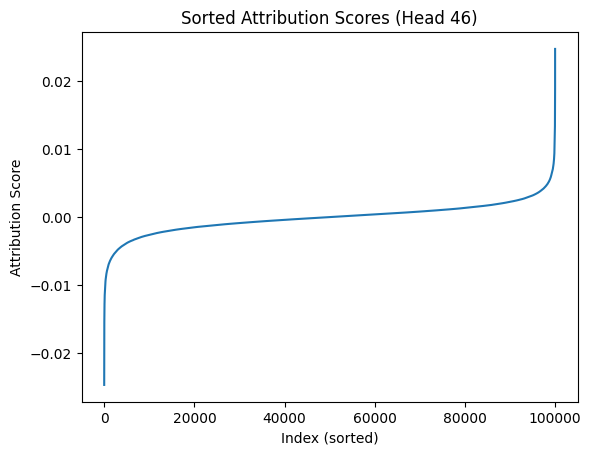

In [9]:
x = loaded['attributions']
# #flatten and plot histogram
# import matplotlib.pyplot as plt
# plt.hist(x.flatten().cpu(), bins=100)
# plt.title("Distribution of Attribution Scores (Head 46)")
# plt.xlabel("Attribution Score")
# plt.ylabel("Frequency")
# plt.show()

# flatten and sort it and plot is as a graph of sorted values
x_flat = x.flatten().cpu()
# first uniformly sample 100k values from x_flat to make the plot faster
sample_size = min(100000, x_flat.shape[0])
sample_indices = torch.randperm(x_flat.shape[0])[:sample_size]
x_sampled = x_flat[sample_indices]
x_sorted, _ = torch.sort(x_sampled)
plt.plot(x_sorted.numpy())
plt.title("Sorted Attribution Scores (Head 46)")
plt.xlabel("Index (sorted)")
plt.ylabel("Attribution Score")
plt.show()

### saving head acts

In [ ]:
import os
import json
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# --- 1. CONFIGURATION ---
IMAGENET_VAL_DIR = '/home/nfm/data_prisma/imagenet_val/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/val/'
# OUTPUT_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_clipvit16_FullFT'
# OUTPUT_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_pure_clipvit16'
OUTPUT_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_pure_clipvit16_newdataset'
LOCAL_JSON_PATH = "/home/nfm/ViT-Prisma/demos/imagenet_class_index.json"

BATCH_SIZE = 50 # 50 images per class. 48GB GPU handles this easily!
LAYERS_TO_KEEP = 4 

os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- 2. LOAD CLASS NAMES ---
with open(LOCAL_JSON_PATH, 'r') as f:
    imagenet_class_index = json.load(f)

wnid_to_name = {}
for idx, (wnid, class_name) in imagenet_class_index.items():
    safe_class_name = class_name.replace(" ", "_").replace("/", "_").replace(",", "")
    wnid_to_name[wnid] = safe_class_name

# --- 3. DATASET & DATALOADER ---
# ImageFolder automatically sorts by folder name, so 50 images per folder = perfect batches
dataset = ImageFolder(IMAGENET_VAL_DIR, transform=transform) 
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# Calculate how many heads we are slicing (4 layers * 12 heads = 48 heads)
num_heads_to_keep = LAYERS_TO_KEEP * model.cfg.n_heads

print(f"Starting extraction. Saving {num_heads_to_keep}x50x{model.cfg.d_model} tensors...")

# --- 4. MAIN EXTRACTION LOOP ---
for batch_imgs, batch_labels in tqdm(dataloader, total=len(dataloader)):
    
    # Get the class info from the first image in the batch
    class_idx = batch_labels[0].item()
    folder_id = dataset.classes[class_idx]
    class_name = wnid_to_name.get(folder_id, "unknown_class")
    
    batch_imgs = batch_imgs.to(model.cfg.device)

    # --- 5. SAVE TO DISK ---
    filename = f"{folder_id}_{class_name}.pt"
    save_path = os.path.join(OUTPUT_DIR, filename)

    # if os.path.exists(save_path):
    #     continue
    
    with torch.no_grad():
        # Run forward pass and cache activations for all 50 images
        _, cache = model.run_with_cache(batch_imgs)
        
        # Extract the CLS token output for ALL heads
        # Shape: [144, 50, 768] (assuming 12 layers)
        all_head_residuals = cache.stack_head_results(layer=-1, pos_slice=0)

        scaled_head_residuals = cache.apply_ln_to_stack(
            all_head_residuals, layer=-1, pos_slice=0
        )
        
        # Slice to keep only the last 4 layers (last 48 indices on the 0th dimension)
        # Shape becomes: [48, 50, 768]
        last_4_layers_residual = scaled_head_residuals[-num_heads_to_keep:, :, :]
        

    
    # Move to CPU before saving to keep VRAM clear
    torch.save(last_4_layers_residual.cpu().clone(), save_path)
    
    # Clear cache and VRAM for the next class
    del cache
    del all_head_residuals
    del last_4_layers_residual
    del scaled_head_residuals
    torch.cuda.empty_cache()

print(f"Extraction complete! Saved to {OUTPUT_DIR}")

In [39]:
IMAGENET_VAL_DIR = '/home/nfm/data_prisma/imagenet_val/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/val/'
dataset = ImageFolder(IMAGENET_VAL_DIR, transform=transform) 
dataloader = DataLoader(dataset, batch_size=50, shuffle=False, num_workers=4)

for i, (batch_imgs, batch_labels) in enumerate(dataloader):
    print(batch_labels[0].item(), end=" ")
    # if i == 15:
    #     break

0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265 266 267 268 269 270 271 272 273 274 275 276 27

In [ ]:
import os
import json
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# --- 1. CONFIGURATION ---
IMAGENET_VAL_DIR = '/home/nfm/data_prisma/imagenet_val/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/val/'
# OUTPUT_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_clipvit16_FullFT'
# OUTPUT_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_pure_clipvit16'
OUTPUT_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_pure_clipvit16_newdataset'
LOCAL_JSON_PATH = "/home/nfm/ViT-Prisma/demos/imagenet_class_index.json"

BATCH_SIZE = 50 # 50 images per class. 48GB GPU handles this easily!
LAYERS_TO_KEEP = 4 

os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- 2. LOAD CLASS NAMES ---
with open(LOCAL_JSON_PATH, 'r') as f:
    imagenet_class_index = json.load(f)

wnid_to_name = {}
for idx, (wnid, class_name) in imagenet_class_index.items():
    safe_class_name = class_name.replace(" ", "_").replace("/", "_").replace(",", "")
    wnid_to_name[wnid] = safe_class_name

# --- 3. DATASET & DATALOADER ---
# ImageFolder automatically sorts by folder name, so 50 images per folder = perfect batches
dataset = ImageFolder(IMAGENET_VAL_DIR, transform=transform) 
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# Calculate how many heads we are slicing (4 layers * 12 heads = 48 heads)
num_heads_to_keep = LAYERS_TO_KEEP * model.cfg.n_heads

print(f"Starting extraction. Saving {num_heads_to_keep}x50x{model.cfg.d_model} tensors...")

# --- 4. MAIN EXTRACTION LOOP ---
for batch_imgs, batch_labels in tqdm(dataloader, total=len(dataloader)):
    
    # Get the class info from the first image in the batch
    class_idx = batch_labels[0].item()
    folder_id = dataset.classes[class_idx]
    class_name = wnid_to_name.get(folder_id, "unknown_class")
    
    batch_imgs = batch_imgs.to(model.cfg.device)

    # --- 5. SAVE TO DISK ---
    filename = f"{folder_id}_{class_name}.pt"
    save_path = os.path.join(OUTPUT_DIR, filename)

    # if os.path.exists(save_path):
    #     continue
    
    with torch.no_grad():
        # Run forward pass and cache activations for all 50 images
        _, cache = model.run_with_cache(batch_imgs)
        
        # Extract the CLS token output for ALL heads
        # Shape: [144, 50, 768] (assuming 12 layers)
        all_head_residuals = cache.stack_head_results(layer=-1, pos_slice=0)

        scaled_head_residuals = cache.apply_ln_to_stack(
            all_head_residuals, layer=-1, pos_slice=0
        )
        
        # Slice to keep only the last 4 layers (last 48 indices on the 0th dimension)
        # Shape becomes: [48, 50, 768]
        last_4_layers_residual = scaled_head_residuals[-num_heads_to_keep:, :, :]
        

    
    # Move to CPU before saving to keep VRAM clear
    torch.save(last_4_layers_residual.cpu().clone(), save_path)
    
    # Clear cache and VRAM for the next class
    del cache
    del all_head_residuals
    del last_4_layers_residual
    del scaled_head_residuals
    torch.cuda.empty_cache()

print(f"Extraction complete! Saved to {OUTPUT_DIR}")

Starting extraction. Saving 48x50x768 tensors...


  0%|          | 0/1000 [00:00<?, ?it/s]

Tried to stack head results when they weren't cached. Computing head results now


  0%|          | 1/1000 [00:01<25:35,  1.54s/it]

Tried to stack head results when they weren't cached. Computing head results now


...

Tried to stack head results when they weren't cached. Computing head results now


100%|█████████▉| 999/1000 [06:22<00:00,  2.68it/s]

Tried to stack head results when they weren't cached. Computing head results now


100%|██████████| 1000/1000 [06:22<00:00,  2.61it/s]

Extraction complete! Saved to /home/nfm/ViT-Prisma/demos/head_acts_pure_clipvit16


### end of saving head acts

In [ ]:
pth1 = "/home/nfm/ViT-Prisma/demos/head_acts_pure_clipvit16/n01440764_tench.pt"
t1 = torch.load(pth1)
# t1 = torch.load(pth1, weights_only=True).to("cuda:0")
# t1[0].shape
pth2 = "/home/nfm/ViT-Prisma/demos/head_acts_clip_linear_probe_real/n01440764_tench.pt"
t2 = torch.load(pth2)
pth3 = "/home/nfm/ViT-Prisma/demos/head_acts_clipvit16_myfullft/n01440764_tench.pt"
t3 = torch.load(pth3)

#check if they are the same
print("Shapes:", t1.shape, t2.shape, t3.shape)
print("Are t1 and t2 close?", torch.allclose(t1, t2))
print("Are t1 and t3 close?", torch.allclose(t1, t3))
print("Are t2 and t3 close?", torch.allclose(t2, t3))

Shapes: torch.Size([48, 50, 768]) torch.Size([48, 50, 768]) torch.Size([48, 50, 768])
Are t1 and t2 close? True
Are t1 and t3 close? False
Are t2 and t3 close? False


In [4]:
txt_pth = "/home/nfm/clip_text_span/text_descriptions/image_descriptions_general.txt"
with open(txt_pth, "r") as f:
    texts = [line.strip() for line in f.readlines()]

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

IMAGENET_VAL_DIR = '/home/nfm/data_prisma/imagenet_val/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/val/'
# OUTPUT_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_clipvit16_FullFT'
LOCAL_JSON_PATH = "/home/nfm/ViT-Prisma/demos/imagenet_class_index.json"

BATCH_SIZE = 50 # 50 images per class. 48GB GPU handles this easily!

dataset = ImageFolder(IMAGENET_VAL_DIR) 
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

In [5]:
# final_tensor = torch.zeros(1000, 48, 50, 1000)
import psutil

import gc
gc.collect()

def ram_info():
    mem = psutil.virtual_memory()
    total = mem.total / (1024 ** 3)
    available = mem.available / (1024 ** 3)
    used = mem.used / (1024 ** 3)
    percent = mem.percent

    print(f"Total RAM: {total:.2f} GB")
    print(f"Available RAM: {available:.2f} GB")
    print(f"Used RAM: {used:.2f} GB ({percent}%)")

ram_info()

Total RAM: 44.12 GB
Available RAM: 21.01 GB
Used RAM: 23.12 GB (52.4%)


In [6]:
# del final_tensor
# model.head.W_H.shape
# text_dict.shape, proj_head.shape, C.shape

In [9]:
import os
import json
import torch
from collections import Counter

TENSORS_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_pure_clipvit16'
LOCAL_JSON_PATH = "/home/nfm/ViT-Prisma/demos/imagenet_class_index.json"
TEXT_DICT_PATH = "/home/nfm/ViT-Prisma/demos/text_dict.pt"

TARGET_HEAD_IDX = 45 
NUM_ITERATIONS = 20  # How many orthogonal texts to find (m in the paper)
TOP_K_METRIC = 500   # Your 'gaga' metric

device = "cuda" if torch.cuda.is_available() else "cpu"

with open(LOCAL_JSON_PATH, 'r') as f:
    imagenet_class_index = json.load(f)
wnid_to_idx = {wnid: int(idx) for idx, (wnid, name) in imagenet_class_index.items()}
text_dict = torch.load(TEXT_DICT_PATH).to(device)
proj_head = model.head.W_H.to(device)
target_direction = text_dict @ proj_head.T  # Shape: [3498, 768]
R = target_direction.clone() 

print(f"Loading 50,000 image residuals for Head Index {TARGET_HEAD_IDX}...")
C = torch.zeros(1000 * 50, 768, device=device) 
pths = [f for f in os.listdir(TENSORS_DIR) if f.endswith('.pt')]

for pth in pths:
    wnid = pth.split('_')[0]
    true_class_idx = wnid_to_idx[wnid]
    filepath = os.path.join(TENSORS_DIR, pth)
    head_residuals = torch.load(filepath, map_location=device, weights_only=True)[TARGET_HEAD_IDX] 
    start_row = true_class_idx * 50
    end_row = start_row + 50
    C[start_row:end_row] = head_residuals

print("Data loaded. Starting Iterative Orthogonal Projection (TextSpan)...")
print("-" * 50)

C = C@proj_head
TOP_K_METRIC = 5000
selected_texts = []
for step in range(NUM_ITERATIONS):
    # dla_scores = torch.matmul(C, R.T)
    dla_scores = torch.matmul(C, text_dict.T)
    values, flat_idx = dla_scores.reshape(-1).topk(TOP_K_METRIC, largest=True)
    
    num_texts = text_dict.shape[0]
    text_indices = flat_idx % num_texts
    
    counts = Counter(text_indices.tolist())
    winning_idx = counts.most_common(1)[0][0]
    winning_text = texts[winning_idx]

    # get the average, also max dla score for the winning text
    winning_text_score = values[text_indices == winning_idx].mean().item()
    max_dla_score = values[text_indices == winning_idx].max().item()
    print(f"Iteration {step + 1}: {winning_text} (Average DLA Score: {winning_text_score:.4f}, Max DLA Score: {max_dla_score:.4f}, Hit Count: {counts[winning_idx]}/{TOP_K_METRIC})")
    
    selected_texts.append(winning_text)
    # print(f"Iteration {step + 1}: {winning_text} (Hit Count: {counts[winning_idx]}/{TOP_K_METRIC})")
    
    # t1 = R[winning_idx].clone()
    # t1_norm = t1 / (t1.norm(p=2) + 1e-8) 
    # projection_C = torch.matmul(C, t1_norm).unsqueeze(1) * t1_norm
    # C = C - projection_C
    # projection_R = torch.matmul(R, t1_norm).unsqueeze(1) * t1_norm
    # R = R - projection_R

    t1 = text_dict[winning_idx]
    t1_unit = t1 / (t1.norm() + 1e-8)  # unit vector along selected direction
    C = C - torch.matmul(C, t1_unit).unsqueeze(1) * t1_unit
    text_dict = text_dict - torch.matmul(text_dict, t1_unit).unsqueeze(1) * t1_unit
    # C = C - torch.matmul(C, t1).unsqueeze(1) * t1
    # text_dict = text_dict - torch.matmul(text_dict, t1).unsqueeze(1) * t1
    # text_dict = torch.nn.functional.normalize(text_dict, dim=-1)


# print("-" * 50)
# print("Final TextSpan Dictionary for this head:")
# for i, txt in enumerate(selected_texts):
#     print(f"{i+1}. {txt}")

Loading 50,000 image residuals for Head Index 45...
Data loaded. Starting Iterative Orthogonal Projection (TextSpan)...
--------------------------------------------------
Iteration 1: An image of the number 4 (Average DLA Score: 0.4713, Max DLA Score: 1.1628, Hit Count: 683/5000)
Iteration 2: The number two (Average DLA Score: 0.5121, Max DLA Score: 1.3036, Hit Count: 92/5000)
Iteration 3: An image of the number 8 (Average DLA Score: 0.4167, Max DLA Score: 1.0339, Hit Count: 132/5000)
Iteration 4: An image of the number 7 (Average DLA Score: 0.4342, Max DLA Score: 1.2455, Hit Count: 136/5000)
Iteration 5: An image of the number 10 (Average DLA Score: 0.4084, Max DLA Score: 1.3341, Hit Count: 113/5000)
Iteration 6: Close-up of a textured leather (Average DLA Score: 0.3571, Max DLA Score: 0.8140, Hit Count: 96/5000)
Iteration 7: A sock (Average DLA Score: 0.3337, Max DLA Score: 0.5748, Hit Count: 74/5000)
Iteration 8: Rustic wooden textures (Average DLA Score: 0.2989, Max DLA Score: 0.46

my approach after adding text_dict = torch.nn.functional.normalize(text_dict, dim=-1) after substracting the selected text
Iteration 1: An image of the number 7 (Hit Count: 32/500)
Iteration 2: An image of the number 2 (Hit Count: 44/500)
Iteration 3: An image of the number 4 (Hit Count: 56/500)
Iteration 4: An image of the number 8 (Hit Count: 61/500)
Iteration 5: An image of the number 5 (Hit Count: 65/500)
Iteration 6: An image of the number 3 (Hit Count: 74/500)
Iteration 7: An image of the number 1 (Hit Count: 96/500)
Iteration 8: An image of the number 9 (Hit Count: 125/500)
Iteration 9: An image of the number 10 (Hit Count: 99/500)
Iteration 10: An image of the number 6 (Hit Count: 34/500)
Iteration 11: The number twelve (Hit Count: 34/500)
Iteration 12: The number six (Hit Count: 28/500)
Iteration 13: A sock (Hit Count: 31/500)
Iteration 14: The number fifteen (Hit Count: 32/500)
Iteration 15: Close-up of a textured leather (Hit Count: 40/500)
Iteration 16: Close-up of a textured synthetic mesh (Hit Count: 43/500)
Iteration 17: Close-up of a textured synthetic wood (Hit Count: 44/500)
Iteration 18: The number thirty (Hit Count: 19/500)
Iteration 19: Play of light (Hit Count: 18/500)
Iteration 20: Play of light and shadow (Hit Count: 16/500)

other persons approach
Iteration 1: An image of the number 7 (Hit Count: 32/500)
Iteration 2: An image of the number 10 (Hit Count: 25/500)
Iteration 3: An image of the number 2 (Hit Count: 29/500)
Iteration 4: The number fifteen (Hit Count: 28/500)
Iteration 5: Image with a four people (Hit Count: 28/500)
Iteration 6: Image with a trio of friends (Hit Count: 33/500)
Iteration 7: Image with a six people (Hit Count: 32/500)
Iteration 8: Close-up of a textured leather (Hit Count: 23/500)
Iteration 9: An image of the number 8 (Hit Count: 22/500)
Iteration 10: An image of the number 5 (Hit Count: 27/500)
Iteration 11: A sock (Hit Count: 25/500)
Iteration 12: Rustic wooden textures (Hit Count: 27/500)
Iteration 13: The number three (Hit Count: 14/500)
Iteration 14: Play of light (Hit Count: 17/500)
Iteration 15: The number twelve (Hit Count: 15/500)
Iteration 16: An image of the number 1 (Hit Count: 18/500)
Iteration 17: An image of the number 9 (Hit Count: 14/500)
Iteration 18: The number six (Hit Count: 10/500)
Iteration 19: Close-up of a textured synthetic mesh (Hit Count: 11/500)
Iteration 20: Emotional and heartfelt friendship (Hit Count: 11/500)

my approach without normalizing the text_dict
Iteration 1: An image of the number 7 (Hit Count: 32/500)
Iteration 2: The number fifteen (Hit Count: 19/500)
Iteration 3: An image of the number 2 (Hit Count: 21/500)
Iteration 4: An image of the number 10 (Hit Count: 20/500)
Iteration 5: An image of the number 8 (Hit Count: 18/500)
Iteration 6: Image with a four people (Hit Count: 20/500)
Iteration 7: Image with three people (Hit Count: 27/500)
Iteration 8: Image with a six people (Hit Count: 29/500)
Iteration 9: An image of the number 5 (Hit Count: 30/500)
Iteration 10: The number twelve (Hit Count: 23/500)
Iteration 11: Close-up of a textured leather (Hit Count: 25/500)
Iteration 12: A sock (Hit Count: 19/500)
Iteration 13: An image of the number 2 (Hit Count: 19/500)
Iteration 14: The number six (Hit Count: 19/500)
Iteration 15: Rustic wooden textures (Hit Count: 17/500)
Iteration 16: Image with a five people (Hit Count: 17/500)
Iteration 17: An image of the number 6 (Hit Count: 17/500)
Iteration 18: An image of the number 3 (Hit Count: 16/500)
Iteration 19: Play of light (Hit Count: 16/500)
Iteration 20: An image of the number 9 (Hit Count: 19/500)

original text span algorithm with variance
An image of the number 10
An image of the number 7
Image with a four people
An image of the number 2
Image with a six people
Rustic wooden textures
Close-up of a textured leather
Image with three people
The number fifteen
An image of the number 8
Close-up of a textured synthetic mesh
An image of the number 9
Play of light
Picture taken in the Scottish castles
The number eleven
Disappointed facial expression
A gem
Glimpse of the past
Reflective cityscape at twilight
The number twenty

my previous direct text attribution approach without any projection after selecting the one text
Analyzing Layer 11 Head 9...
An image of the number 7: 32 : 0.748||An image of the number 2: 30 : 0.757||The number two: 28 : 0.733||An image of the number 10: 27 : 0.823||The number fifteen: 27 : 0.749||An image of the number 5: 22 : 0.820||The number six: 20 : 0.739||The number twelve: 19 : 0.810||An image of the number 8: 19 : 0.749||Image with a four people: 19 : 0.758||The number five: 18 : 0.820||An image of the number 4: 18 : 0.729||The number seven: 17 : 0.742||An image of the number 3: 15 : 0.741||An image of the number 6: 15 : 0.731||Image with a five people: 13 : 0.881||Close-up of a textured leather: 12 : 0.725||Image with a seven people: 12 : 0.704||Image with five subjects: 11 : 0.795||The number three: 11 : 0.719||


are the differences interpretable or random. for instance, for some reason when I add normalization in my approach, the texts like "images with four people" disapead, I just see numbers and textures. but for the rest, I see numbers by themselves, number of peoples as well, and also textures

In [6]:
import os
import json
import torch
from torch import einsum

# TENSORS_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_vitpatch16'
# TENSORS_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_clip_linear_probe_real'
# ggg = "Linear Probe CLIP"
# TENSORS_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_clipvit16_FullFT'
# ggg = "TIMM Full FT CLIP"
# TENSORS_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_clipvit16_myfullft'
# ggg = "My Full FT CLIP"
TENSORS_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_pure_clipvit16'
ggg = "Original Clip"

LOCAL_JSON_PATH = "/home/nfm/ViT-Prisma/demos/imagenet_class_index.json"

# Load the JSON to create a bulletproof WNID -> Integer Index mapping
with open(LOCAL_JSON_PATH, 'r') as f:
    imagenet_class_index = json.load(f)

# Create a reverse lookup: "n01440764" -> 0
wnid_to_idx = {wnid: int(idx) for idx, (wnid, name) in imagenet_class_index.items()}
idx_to_name = {int(idx): name for idx, (wnid, name) in imagenet_class_index.items()}

def residual_stack_to_logit_attn(centered_residual_stack, answer_residual_direction):
    # This subtracts the mean across the d_model dimension (dim=-1)
    # centered_residual_stack = residual_stack - residual_stack.mean(dim=-1, keepdim=True)
    
    raw_dla = torch.einsum(
        "h b d, c d -> h b c",  # h=heads, b=batch, d=d_model, c=classes
        centered_residual_stack,
        answer_residual_direction,
    )
    return raw_dla 

# --- 3. BUILD THE FINAL TENSOR ---
text_dict = torch.load("/home/nfm/ViT-Prisma/demos/text_dict.pt")
txt_pth = "/home/nfm/clip_text_span/text_descriptions/image_descriptions_general.txt"
with open(txt_pth, "r") as f:
    texts = [line.strip() for line in f.readlines()]
for_print = "With 3500 general text descriptions, model:" + ggg

# text_dict = torch.load("/home/nfm/ViT-Prisma/demos/text_dict_imagenet.pt")
# text_dict = text_dict.to("cuda")
# texts = [idx_to_name[i] for i in range(1000)]
# for_print = "With 1000 ImageNet class name descriptions, model:" + ggg

print(for_print)


proj_head = model.head.W_H
target_direction = text_dict @ proj_head.T
target_direction = target_direction.to(model.cfg.device)

start_inds = [0, 12, 24, 36]
start_inds = [45]
for xx in start_inds:
    # xx = 0
    head_idx = [xx+i for i in range(12)] # last 4 layers, all heads
    head_idx = [i for i in head_idx if i < 48]

    # head_idx = [5, 6, 10, 8, -2]
    # head_idx = [3, 4, 9, 2-12, 6-12]
    # head_idx = [i+36 for i in head_idx]

    final_tensor = torch.zeros(1000,len(head_idx), 50, len(texts)) # [ImageClass, Head, LogitClass]

    pths = [f for f in os.listdir(TENSORS_DIR) if f.endswith('.pt')]


    # print("Calculating DLA and aligning indices...")
    for pth in pths:
        # Extract the WNID from the filename (e.g., 'n01440764_tench.pt' -> 'n01440764')
        wnid = pth.split('_')[0]
        
        # Find its exact 0-999 integer index
        true_class_idx = wnid_to_idx[wnid]
        
        # Load and compute
        filepath = os.path.join(TENSORS_DIR, pth)
        per_head_residual = torch.load(filepath, weights_only=True).to(model.cfg.device) 
        
        per_head_attribution = residual_stack_to_logit_attn(per_head_residual[head_idx], target_direction)
        
        # Insert it into the EXACT right row based on its official ImageNet index
        final_tensor[true_class_idx] = per_head_attribution.cpu()

    final_tensor = final_tensor.detach().cpu()
    # print("Final tensor shape:", final_tensor.shape)
    # continue
    for shibu in range(len(head_idx)):
        print(f"Analyzing Layer {8+head_idx[shibu]//12} Head {head_idx[shibu]%12}...")    
        temp = torch.clone(final_tensor[:,shibu,:,:])
        gaga = 500
        values, flat_idx = temp.reshape(-1).topk(gaga, largest=True)

        # unravel flat indices to 3D coords
        A, B, C = temp.shape
        i = flat_idx // (B * C)
        j = (flat_idx % (B * C)) // C
        k = flat_idx % C
        indices = torch.stack([i, j, k], dim=1)


        top_names = []
        avg_vals = {}
        for i in range(gaga):
            top_names.append(texts[indices[i][2].item()])
            avg_vals[texts[indices[i][2].item()]] = avg_vals.get(texts[indices[i][2].item()], []) + [values[i].item()]

        #sort avg_vals by mean value
        # avg_vals = {k: sum(v)/len(v) for k, v in avg_vals.items()}
        # avg_vals = dict(sorted(avg_vals.items(), key=lambda item: item[1], reverse=True))


        from collections import Counter
        name_counts = Counter(top_names)
        # print(name_counts.most_common(20))
        # print(list(avg_vals.items())[:20])
        for name, count in name_counts.most_common(20):
            print(f"{name}: {count} : {sum(avg_vals[name])/len(avg_vals[name]):.3f}", end="||")
        print("\n" + "-"*50)

With 3500 general text descriptions, model:Original Clip
Analyzing Layer 11 Head 9...
An image of the number 7: 32 : 0.748||An image of the number 2: 30 : 0.757||The number two: 28 : 0.733||An image of the number 10: 27 : 0.823||The number fifteen: 27 : 0.749||An image of the number 5: 22 : 0.820||The number six: 20 : 0.739||The number twelve: 19 : 0.810||An image of the number 8: 19 : 0.749||Image with a four people: 19 : 0.758||The number five: 18 : 0.820||An image of the number 4: 18 : 0.729||The number seven: 17 : 0.742||An image of the number 3: 15 : 0.741||An image of the number 6: 15 : 0.731||Image with a five people: 13 : 0.881||Close-up of a textured leather: 12 : 0.725||Image with a seven people: 12 : 0.704||Image with five subjects: 11 : 0.795||The number three: 11 : 0.719||
--------------------------------------------------
Analyzing Layer 11 Head 10...
Image with a green color: 96 : 2.006||An image with cold green tones: 94 : 2.018||Image with a blue color: 64 : 2.171||Ima

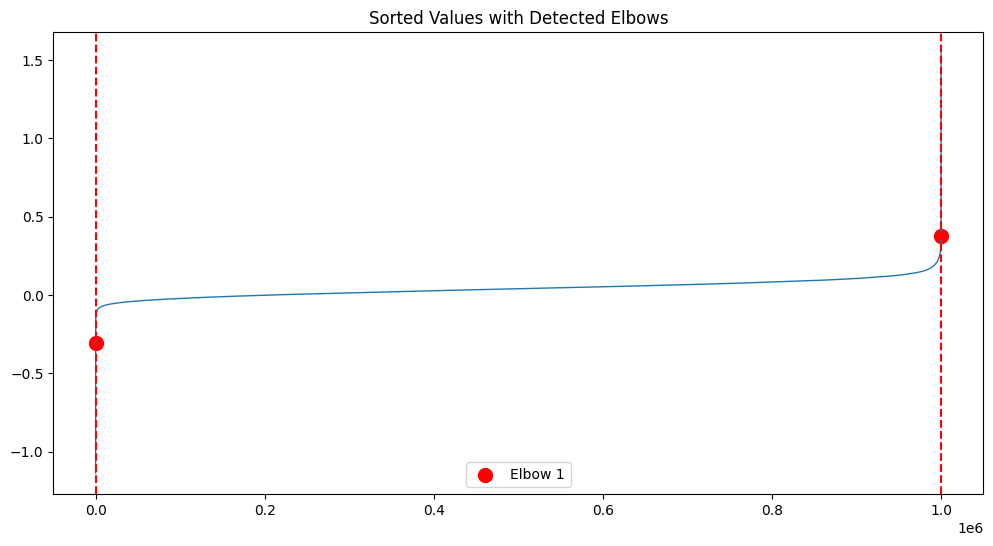

Elbow indices: [     4 999939]
Elbow values: [-0.30577955  0.3748442 ]


In [40]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

temp = final_tensor[:, 2, :, :].flatten()
temp_sorted = torch.sort(temp).values

num_plot = 1_000_000
idx = torch.arange(
    num_plot,
    device=temp_sorted.device
) * (temp_sorted.shape[0] - 1) // (num_plot - 1)
y = temp_sorted[idx].float().cpu().numpy()
x = np.linspace(0, 1, len(y))
y_smooth = gaussian_filter1d(y, sigma=500)


dy = np.gradient(y_smooth)
d2y = np.gradient(dy)
curvature = np.abs(d2y)
peaks, _ = find_peaks(
    curvature,
    distance=len(curvature)//5,
    prominence=np.max(curvature) * 0.1
)

top2 = peaks[np.argsort(curvature[peaks])[-2:]]
top2 = np.sort(top2)


plt.figure(figsize=(12, 6))
plt.plot(y, linewidth=1)

for i, p in enumerate(top2):
    plt.axvline(p, color='red', linestyle='--')
    plt.scatter(
        p,
        y[p],
        color='red',
        s=100,
        label=f'Elbow {i+1}' if i == 0 else None
    )

plt.legend()
plt.title("Sorted Values with Detected Elbows")

plt.show()

print("Elbow indices:", top2)
print("Elbow values:", y[top2])

In [41]:
thresh = y[top2][1].item()
# number of values above threshold from temp
num_above_thresh = (temp > thresh).sum().item()
print(f"Number of values above the second elbow threshold ({thresh:.3f}): {num_above_thresh} out of {temp.numel()} ({num_above_thresh/temp.numel() * 100:.2f}%)")

thresh2 = y[top2][0].item()
#num below threshold
num_below_thresh2 = (temp < thresh2).sum().item()
print(f"Number of values below the first elbow threshold ({thresh2:.3f}): {num_below_thresh2} out of {temp.numel()} ({num_below_thresh2/temp.numel() * 100:.2f}%)")

Number of values above the second elbow threshold (0.375): 10495 out of 174900000 (0.01%)
Number of values below the first elbow threshold (-0.306): 699 out of 174900000 (0.00%)


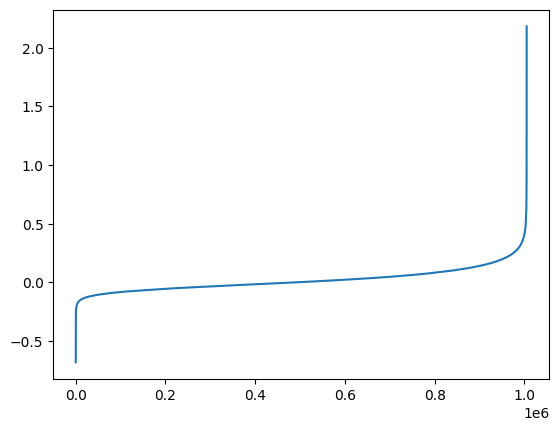

In [67]:
temp = final_tensor[:, 2, :, :].flatten()
# sample 1000000 points to plot them, not histogram, equally spaced sampling, first identify the ideal interval
total_points = temp.shape[0]
interval = total_points // 1000000
sampled_points = temp[::interval]

#sort sampled_points
sampled_points = torch.sort(sampled_points).values

plt.plot(sampled_points.cpu().numpy())

### before rand plots

In [7]:
txt_pth = "/home/nfm/clip_text_span/text_descriptions/image_descriptions_general.txt"
with open(txt_pth, "r") as f:
    texts = [line.strip() for line in f.readlines()]

indices_dict = torch.load("/home/nfm/ViT-Prisma/demos/indices_forclip_dict.pt", weights_only=False)

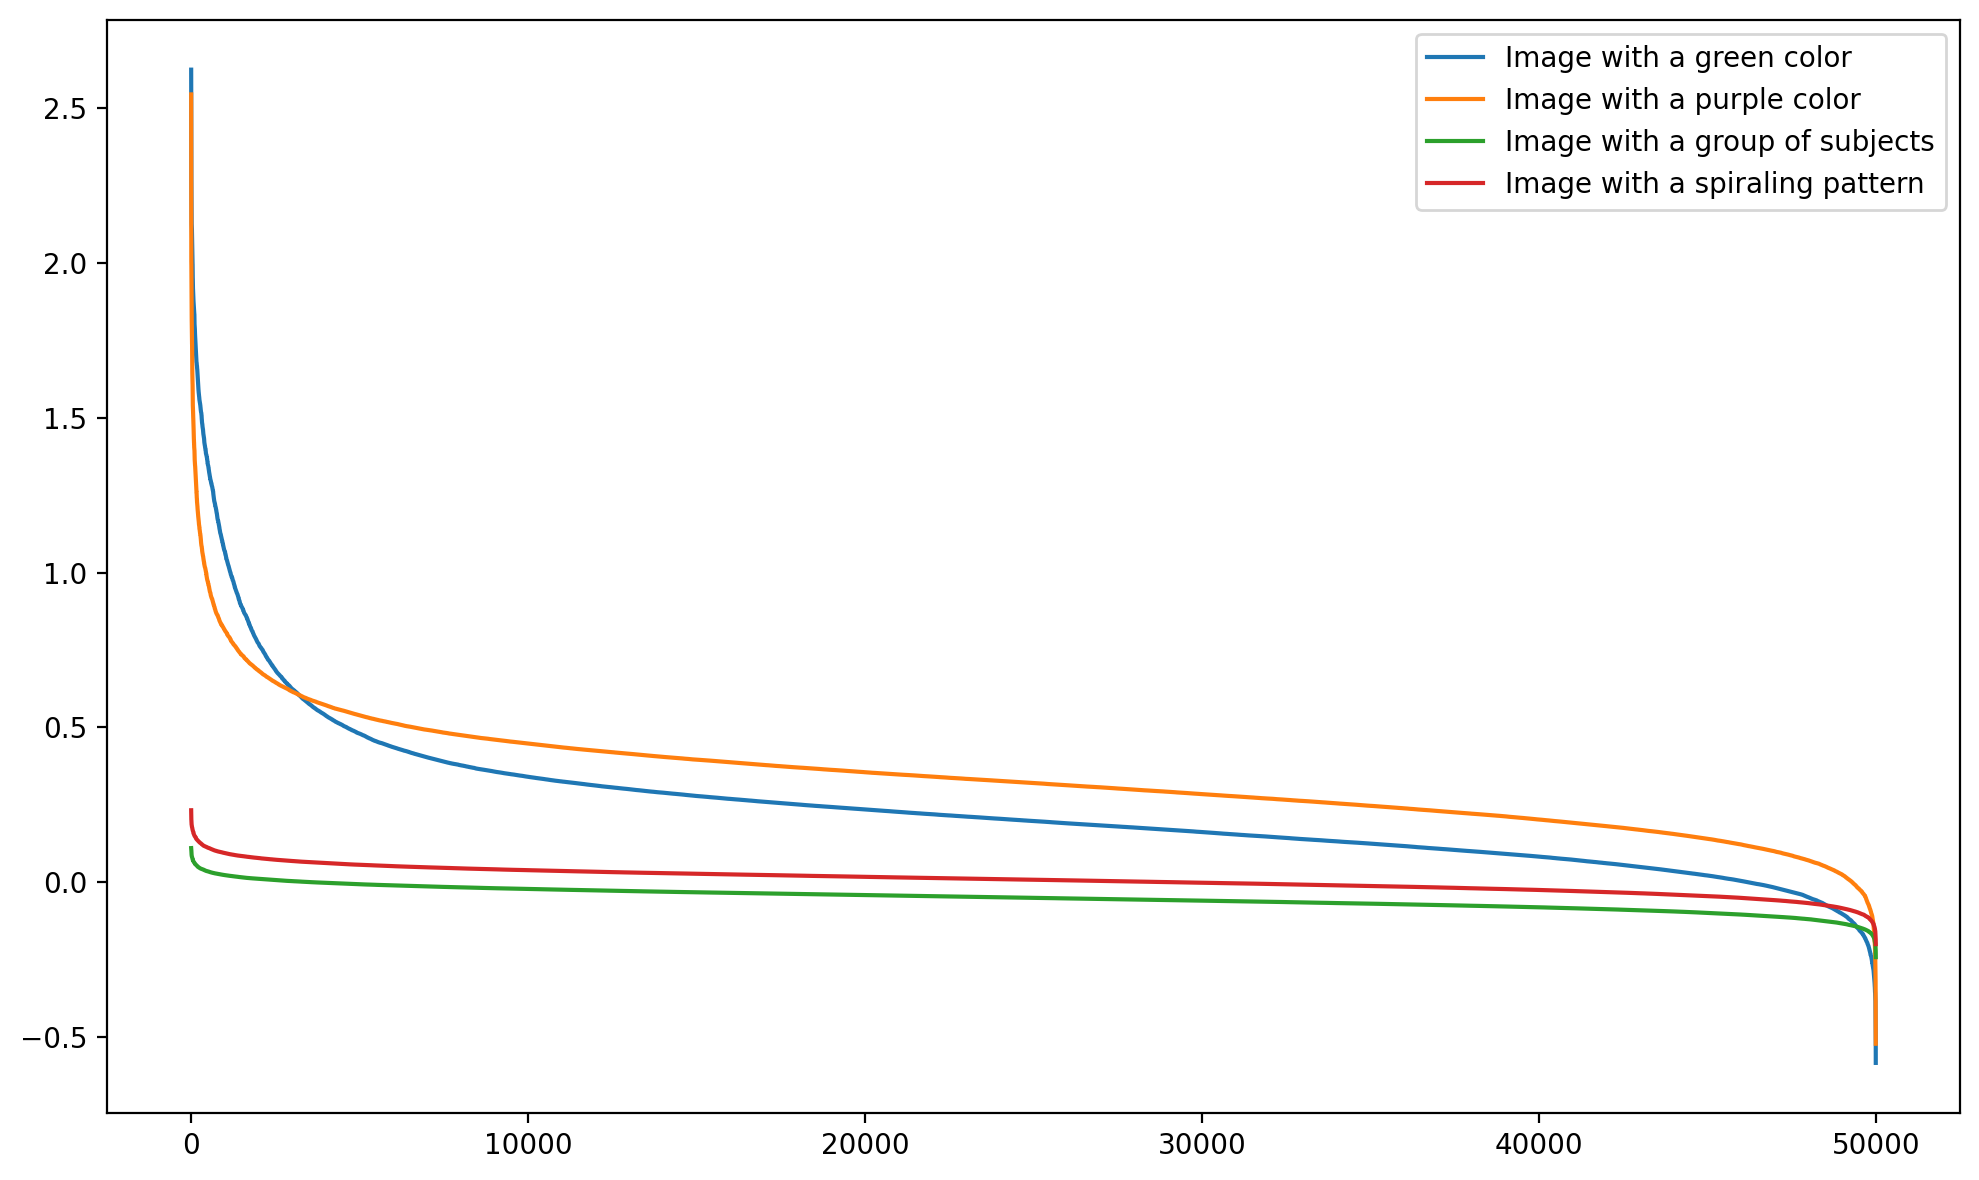

In [12]:
# txt = "Image with a green color"
# idx = texts.index(txt)
# img_inds = indices_dict[idx]
# temp = final_tensor[:, 1, :, idx].flatten()
# #sort temp
# temp = temp[torch.argsort(temp, descending=True)]
# plt.plot(temp.numpy(), label=txt)

# txt = "Image with a purple color"
# idx = texts.index(txt)
# img_inds = indices_dict[idx]
# temp = final_tensor[:, 1, :, idx].flatten()
# #sort temp
# temp = temp[torch.argsort(temp, descending=True)]
# plt.plot(temp.numpy(), label=txt)

# txt = "Image with a group of subjects"
# idx = texts.index(txt)
# img_inds = indices_dict[idx]
# temp = final_tensor[:, 1, :, idx].flatten()
# #sort temp
# temp = temp[torch.argsort(temp, descending=True)]
# plt.plot(temp.numpy(), label=txt)

# txt = "Image with a spiraling pattern"
# idx = texts.index(txt)
# img_inds = indices_dict[idx]
# temp = final_tensor[:, 1, :, idx].flatten()
# #sort temp
# temp = temp[torch.argsort(temp, descending=True)]
# plt.plot(temp.numpy(), label=txt)


# plt.legend()
# plt.show()
import matplotlib.pyplot as plt
import torch

plt.figure(figsize=(10, 6), dpi=200)  # higher dpi for display

for txt in [
    "Image with a green color",
    "Image with a purple color",
    "Image with a group of subjects",
    "Image with a spiraling pattern"
]:
    idx = texts.index(txt)
    temp = final_tensor[:, 1, :, idx].flatten()

    # sort temp
    temp = temp[torch.argsort(temp, descending=True)]

    plt.plot(temp.numpy(), label=txt)

plt.legend()
plt.tight_layout()

# Save high-resolution image
plt.savefig("high_res_plot.png", dpi=300, bbox_inches="tight")

plt.show()

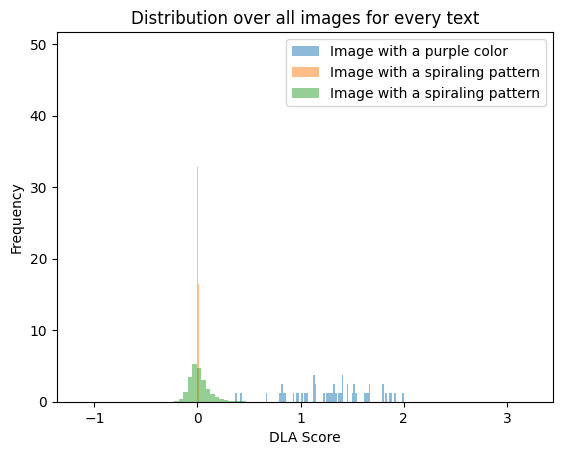

In [120]:
txt = "Image with a purple color"
idx = texts.index(txt)
img_inds = indices_dict[idx]
temp = final_tensor[:, 1, :, idx].flatten()
temp = temp[img_inds]
plt.hist(temp.numpy(), bins=100, density=True, alpha=0.5, label=txt)
plt.title(f"Distribution of DLA Scores for {txt}")
plt.xlabel("DLA Score")
plt.ylabel("Frequency")


txt = "Image with a spiraling pattern"
idx = texts.index(txt)
img_inds = indices_dict[idx]
temp = final_tensor[:, 1, :, idx].flatten()
temp = temp[img_inds]
plt.hist(temp.numpy(), bins=100, density=True, alpha=0.5, label=txt)
plt.title(f"Distribution of DLA Scores for {txt}")
plt.xlabel("DLA Score")
plt.ylabel("Frequency")


txt = "Image with a spiraling pattern"
idx = texts.index(txt)
img_inds = indices_dict[idx]
temp = final_tensor[:, 1, :, :].flatten()
# temp = temp[img_inds]
plt.hist(temp.numpy(), bins=100, density=True, alpha=0.5, label=txt)
plt.title(f"Distribution over all images for every text")
plt.xlabel("DLA Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

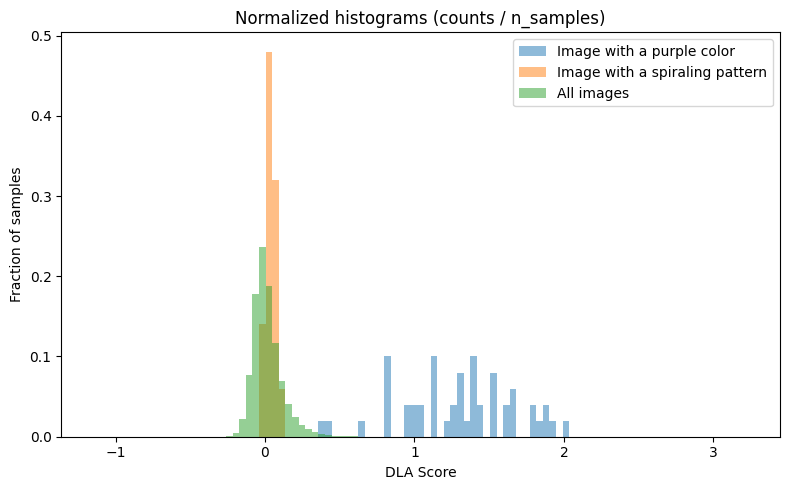

In [121]:
import numpy as np
import matplotlib.pyplot as plt

# build 1D numpy arrays for each case
txt1 = "Image with a purple color"
idx = texts.index(txt1); img_inds = indices_dict[idx]
a1 = final_tensor[:, 1, :, idx].flatten()[img_inds].numpy()

txt2 = "Image with a spiraling pattern"
idx = texts.index(txt2); img_inds = indices_dict[idx]
a2 = final_tensor[:, 1, :, idx].flatten()[img_inds].numpy()

# all images
a3 = final_tensor[:, 1, :, :].flatten().numpy()

arrays = [a1, a2, a3]
labels = [txt1, txt2, "All images"]

# common bins
data_min = min(arr.min() for arr in arrays)
data_max = max(arr.max() for arr in arrays)
bins = np.linspace(data_min, data_max, 100)

plt.figure(figsize=(8,5))
for arr, label in zip(arrays, labels):
    weights = np.ones_like(arr) / arr.size            # normalizes counts by sample count
    plt.hist(arr, bins=bins, weights=weights, alpha=0.5, label=label)

plt.title("Normalized histograms (counts / n_samples)")
plt.xlabel("DLA Score")
plt.ylabel("Fraction of samples")
plt.legend()
plt.tight_layout()
plt.show()

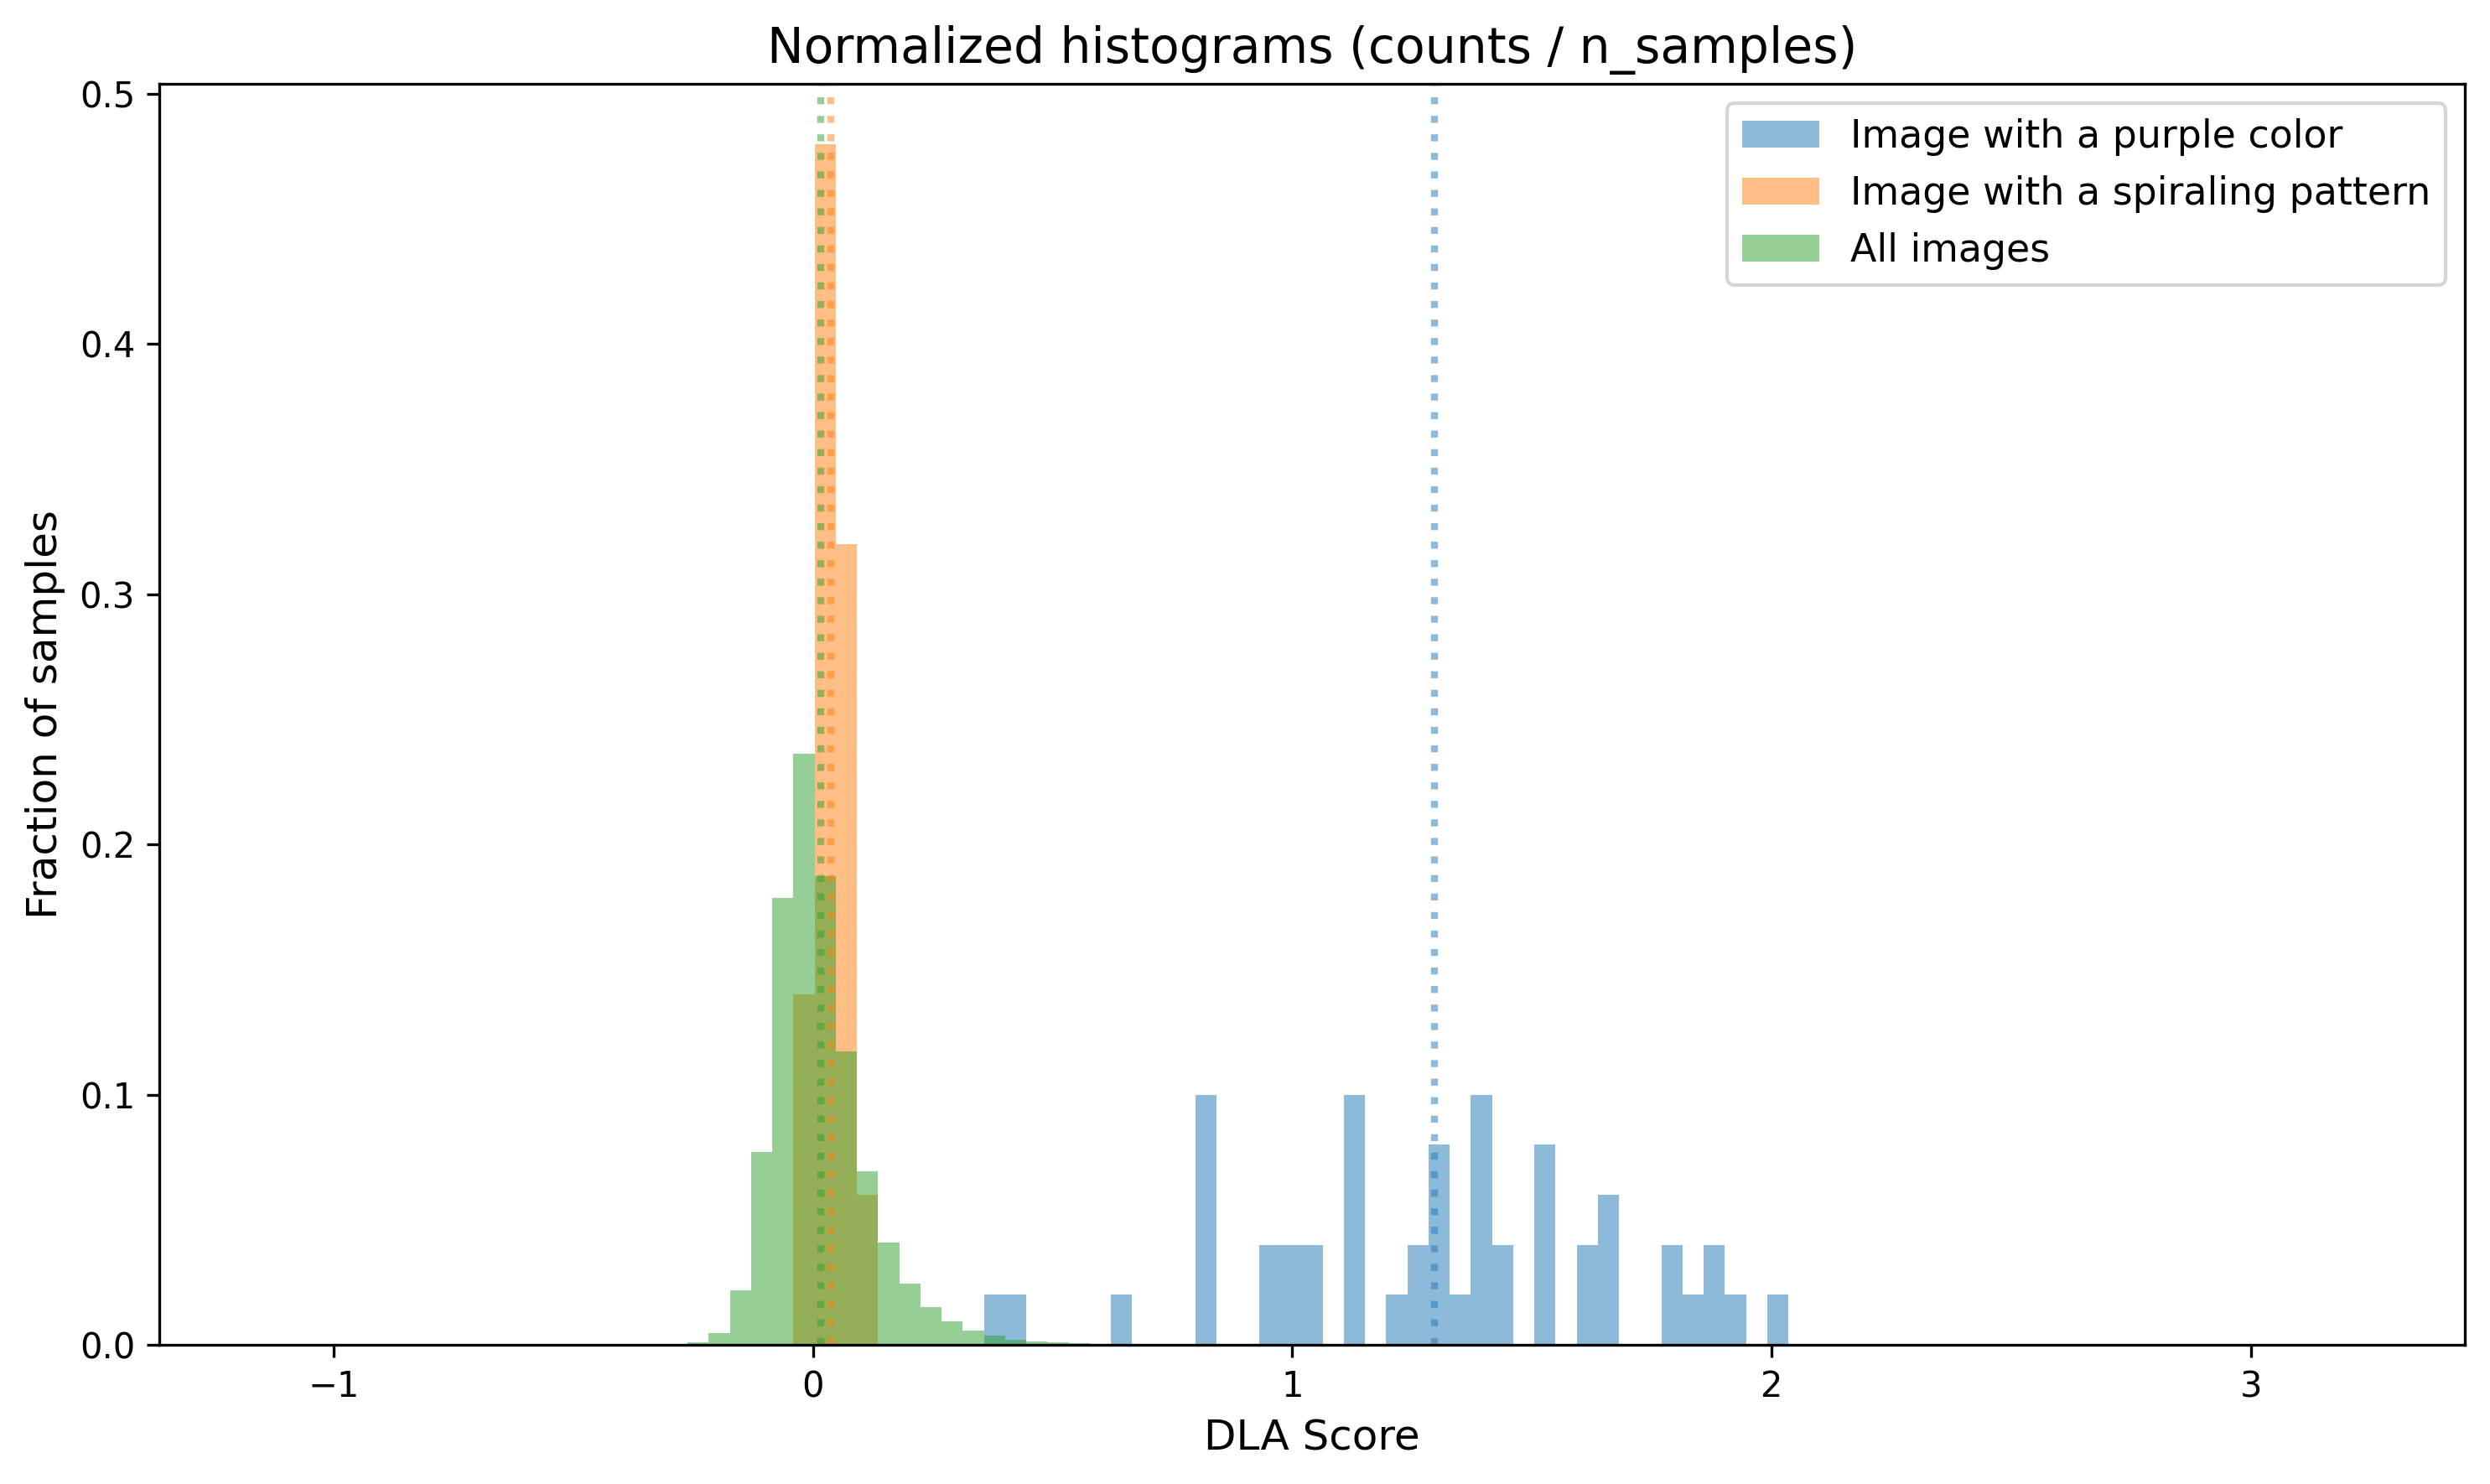

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# build 1D numpy arrays for each case
txt1 = "Image with a purple color"
idx = texts.index(txt1)
img_inds = indices_dict[idx]
a1 = final_tensor[:, 1, :, idx].flatten()[img_inds].numpy()

txt2 = "Image with a spiraling pattern"
idx = texts.index(txt2)
img_inds = indices_dict[idx]
a2 = final_tensor[:, 1, :, idx].flatten()[img_inds].numpy()

# all images
a3 = final_tensor[:, 1, :, :].flatten().numpy()

arrays = [a1, a2, a3]
labels = [txt1, txt2, "All images"]

# common bins
data_min = min(arr.min() for arr in arrays)
data_max = max(arr.max() for arr in arrays)
bins = np.linspace(data_min, data_max, 100)

# High-resolution figure
plt.figure(figsize=(10, 6), dpi=300)

for arr, label in zip(arrays, labels):
    weights = np.ones_like(arr) / arr.size  # normalize counts

    # Plot histogram and capture color
    n, b, patches = plt.hist(
        arr,
        bins=bins,
        weights=weights,
        alpha=0.5,
        label=label
    )

    # Get histogram color
    color = patches[0].get_facecolor()

    # Mean value
    mean_val = arr.mean()

    # Vertical dotted line at mean
    plt.axvline(
        mean_val,
        color=color,
        linestyle=":",
        linewidth=2
    )

plt.title("Normalized histograms (counts / n_samples)", fontsize=14)
plt.xlabel("DLA Score", fontsize=12)
plt.ylabel("Fraction of samples", fontsize=12)
plt.legend(fontsize=11)

plt.tight_layout()

# Save high-resolution version
plt.savefig("normalized_histograms_highres.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [ ]:
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

avgs = []
stds = []

for i in tqdm(range(len(texts))):
    # txt = "Image with a red color"
    # txt = "Image with a futuristic terraforming project"
    txt = texts[i]
    idx = texts.index(txt)
    img_inds = indices_dict[idx]
    temp = final_tensor[:, 1, :, idx].flatten()
    #sort temp
    temp = temp[torch.argsort(temp, descending=True)]
    # plt.plot(temp.numpy(), color="blue")
    # apply abs and average
    avg = temp.abs().mean().item()
    std = temp.abs().std().item()
    avgs.append((txt, avg, std))


# plt.plot(temp.numpy())
# plt.show()
# plt.hist(temp.numpy(), bins=100);

100%|██████████| 3498/3498 [00:23<00:00, 147.20it/s]


Top 20 most activating prompts for Layer 11 Head 10:
Sepia-toned photograph: 0.4611 ± 0.2124
Vintage sepia tones: 0.4591 ± 0.2177
Photo with sepia-toned vintage style: 0.3778 ± 0.1758
A grey color: 0.3778 ± 0.2321
A charcoal gray color: 0.3505 ± 0.2375
An amber color: 0.3389 ± 0.2018
Image with a purple color: 0.3386 ± 0.1818
Image with holographic neon lights: 0.3330 ± 0.1421
Image with a brown color: 0.3314 ± 0.1996
Image with holographic holograms: 0.3270 ± 0.1197
A gold color: 0.3250 ± 0.1887
Image with holographic retro aesthetics: 0.3249 ± 0.1307
Image with holographic retro vaporwave aesthetics: 0.3230 ± 0.1652
An image with cold green tones: 0.3196 ± 0.2503
Muted urban tones: 0.3148 ± 0.1514
Photograph with a brown color palette: 0.3143 ± 0.1814
Image with holographic digital rain: 0.3138 ± 0.1094
Photograph with a purple color palette: 0.3127 ± 0.1694
Image with holographic retro-futurism: 0.3117 ± 0.1256
Image with holographic reflections: 0.3092 ± 0.1133


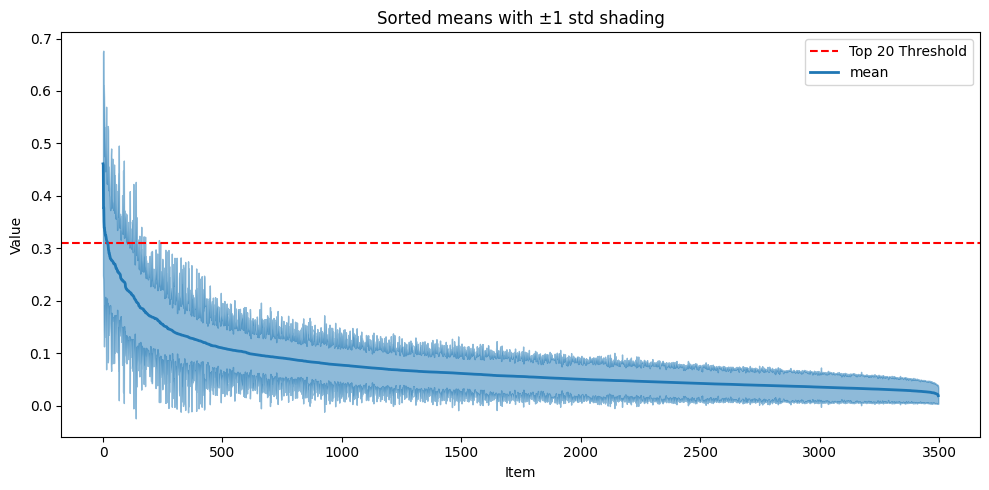

In [103]:
# txt = "Image with a purple color"
# txt = "Image with a futuristic terraforming project"
# # pring avg value for this txt
# for t, avg in avgs:
#     if t == txt:
#         print(f"Average absolute DLA for '{txt}': {avg:.4f}")

# sort avgs by avg value
avgs = sorted(avgs, key=lambda x: x[1], reverse=True)
# print top 20
print("Top 20 most activating prompts for Layer 11 Head 10:")
for txt, avg, std in avgs[0:20]:
    print(f"{txt}: {avg:.4f} ± {std:.4f}")
# plot all means with error bars using the std as shade
import numpy as np
import matplotlib.pyplot as plt

labels = [t[0] for t in avgs]
means = np.array([t[1] for t in avgs])
stds  = np.array([t[2] for t in avgs])

x = np.arange(len(means))

# add line to show the top 20 threshold


plt.figure(figsize=(10,5))
threshold = avgs[19][1]
plt.axhline(y=threshold, color='red', linestyle='--', label='Top 20 Threshold')
plt.fill_between(x, means - stds, means + stds, color='C0', alpha=0.5)
plt.plot(x, means, color='C0', linewidth=2, label='mean')
plt.xlabel('Item')
plt.ylabel('Value')
plt.title('Sorted means with ±1 std shading')
# plt.xticks(x, labels, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

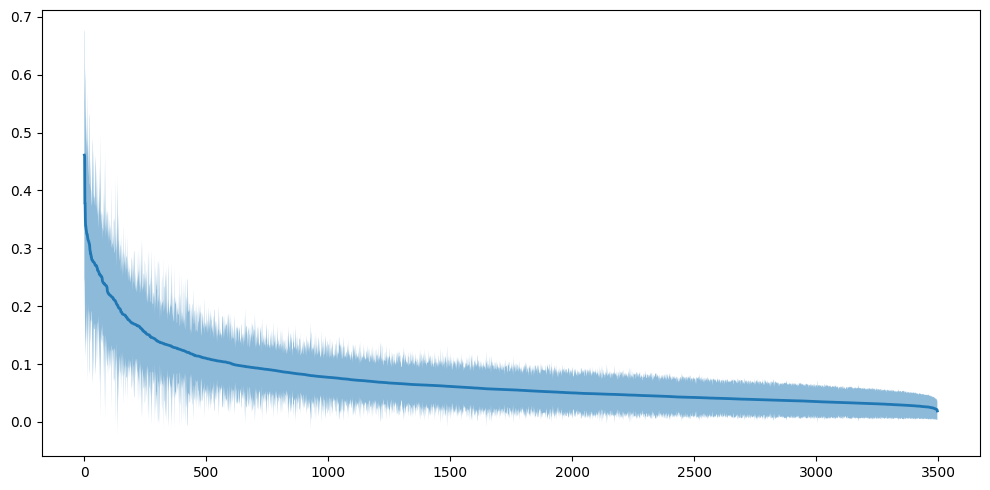

In [81]:
import numpy as np
import matplotlib.pyplot as plt

labels = [t[0] for t in avgs]
means = np.array([t[1] for t in avgs])
stds  = np.array([t[2] for t in avgs])
x = np.arange(len(means))

plt.close('all')
fig, ax = plt.subplots(figsize=(10,5))
ax.fill_between(x, means - stds, means + stds,
                color='C0', alpha=0.5, edgecolor=None, linewidth=0, zorder=1)
ax.plot(x, means, color='C0', linewidth=2, zorder=2)
# ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [98]:
scores = []
scores_inclass = []

for i in tqdm(range(len(texts))):
    # txt = "Image with a red color"
    # txt = "Image with a futuristic terraforming project"
    txt = texts[i]
    idx = texts.index(txt)
    img_inds = indices_dict[idx]
    temp = final_tensor[:, 1, :, idx].flatten()
    in_class = temp[img_inds].mean()
    out_class = temp.mean() - in_class
    score = in_class - out_class
    scores.append((txt, score))
    scores_inclass.append((txt, in_class))

100%|██████████| 3498/3498 [00:06<00:00, 573.32it/s]


In [105]:
scores_inclass = sorted(scores_inclass, key=lambda x: x[1], reverse=True)
for txt, score in scores_inclass[0:20]:
    print(f"{txt}: {score:.4f}")
print("\n" + "="*50 + "\n")
scores = sorted(scores, key=lambda x: x[1], reverse=True)
for txt, score in scores[0:20]:
    print(f"{txt}: {score:.4f}")

Image with a pink color: 1.5150
Image with a yellow color: 1.3615
Image with a green color: 1.3211
Image with a purple color: 1.2973
Image with a blue color: 1.2594
Image with a orange color: 1.2593
An image with cold green tones: 1.1913
Photograph with a blue color palette: 1.1270
Photograph with a yellow color palette: 1.1165
A rainbow: 1.1137
Photograph with a purple color palette: 1.0586
Colorful diversity: 1.0468
Photograph with a green color palette: 0.9928
Image with a red color: 0.9765
Dreamy misty morning: 0.9671
Mystical fog: 0.9645
colorful representation: 0.9554
A charcoal gray color: 0.9478
Tranquil morning mist: 0.9469
Photograph with a red color palette: 0.9267


Image with a pink color: 2.8593
Image with a yellow color: 2.4209
Image with a green color: 2.4005
Image with a blue color: 2.2967
Image with a purple color: 2.2577
Image with a orange color: 2.2496
An image with cold green tones: 2.0737
A rainbow: 2.0584
Photograph with a blue color palette: 2.0490
Colorful div

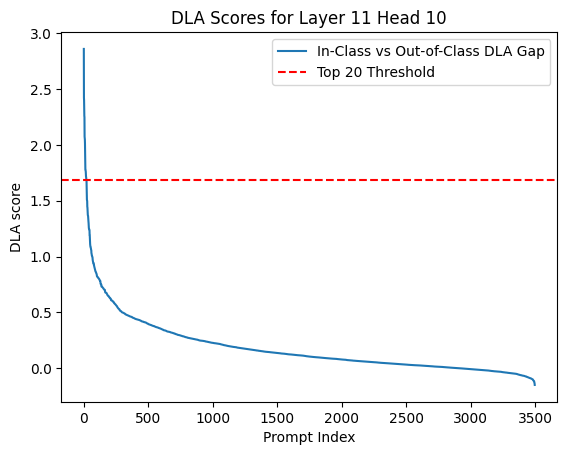

In [113]:
# txt = "Image with a red color"
# txt = "Image with a futuristic terraforming project"
# idx = texts.index(txt)
# scores_inclass[idx], scores[idx]

arr1 = np.array([s[1] for s in scores])
arr2 = np.array([s[1] for s in scores_inclass])

#sort arr1 and arr2 decreasing order based on arr1
# arr1 = arr1[np.argsort(arr1)[::-1]]
# arr2 = arr2[np.argsort(arr2)[::-1]]

plt.plot(arr1, label="In-Class vs Out-of-Class DLA Gap")
# add line to show the top 20 threshold
threshold = scores[19][1]
plt.axhline(y=threshold, color='red', linestyle='--', label='Top 20 Threshold')
# plt.plot(arr2, label="In-Class DLA Mean")
plt.legend()
plt.title("DLA Scores for Layer 11 Head 10")
plt.xlabel("Prompt Index")
plt.ylabel("DLA score")
plt.show()

An image of the number 10


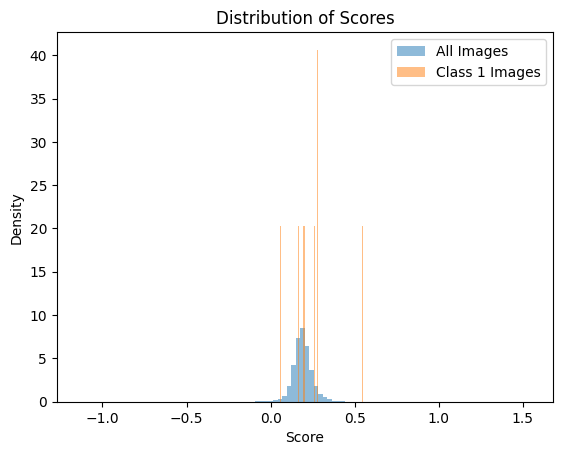

In [153]:
txt1 = "Image with a green color"
txt2 = "Image with a red color"
txt = "Image with a futuristic terraforming project"
idx = texts.index(txt)

color_txts = [txt for txt in texts if "number" in txt]
mytxt = random.choice(color_txts)
print(mytxt)

idx1 = texts.index(txt1)
idx2 = texts.index(txt2)

idx1 = texts.index(mytxt)

img_inds = indices_dict[idx1][40:]

temp = final_tensor[:, 0, :, idx1].flatten()

# plt.hist(temp.numpy(), bins=100)

temp_cls1 = temp[img_inds]
# temp_cls1.shape
plt.hist(temp.numpy(), bins=100, density=True, alpha=0.5, label="All Images");
plt.hist(temp_cls1.numpy(), bins=100, density=True, alpha=0.5, label="Class 1 Images");
plt.xlabel("Score")
plt.ylabel("Density")
plt.title("Distribution of Scores")
plt.legend()
plt.show();

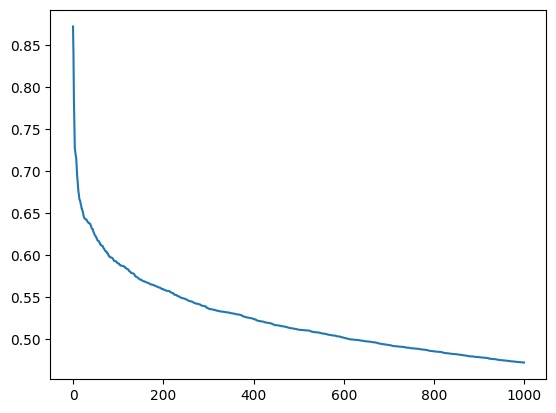

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. Isolate the head and flatten (175,000,000 scores)
temp = final_tensor[:, -1, :, :].flatten()
# sort temp
K = 200000
top_scores, _ = torch.topk(temp, k=K)
top_scores_np = top_scores[:1000].detach().cpu().numpy()

# get first order difference of top_scores_np
# first_order_diff = np.diff(top_scores_np)
plt.plot(top_scores_np)
# plt.plot(first_order_diff[:100])
# plt.hist(temp.cpu().numpy(), bins=500, log=True);



2026-04-27 11:39:55 DEBUG:matplotlib.ticker: vmin 0.42606087590390934 vmax 60408107.0466668
2026-04-27 11:39:55 DEBUG:matplotlib.ticker: ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05,
       1.e+06, 1.e+07, 1.e+08, 1.e+09])
2026-04-27 11:39:55 DEBUG:matplotlib.ticker: vmin 0.42606087590390934 vmax 60408107.0466668
2026-04-27 11:39:55 DEBUG:matplotlib.ticker: ticklocs array([2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6.e+04, 7.e+04, 8.e+04, 9.e+04,
       2.e+05, 3.e+05, 4.e+05, 5.e+05, 6.e+05, 7.e+05, 8.e+05, 9.e+05,
       2.e+06, 3.e+06, 4.e+06

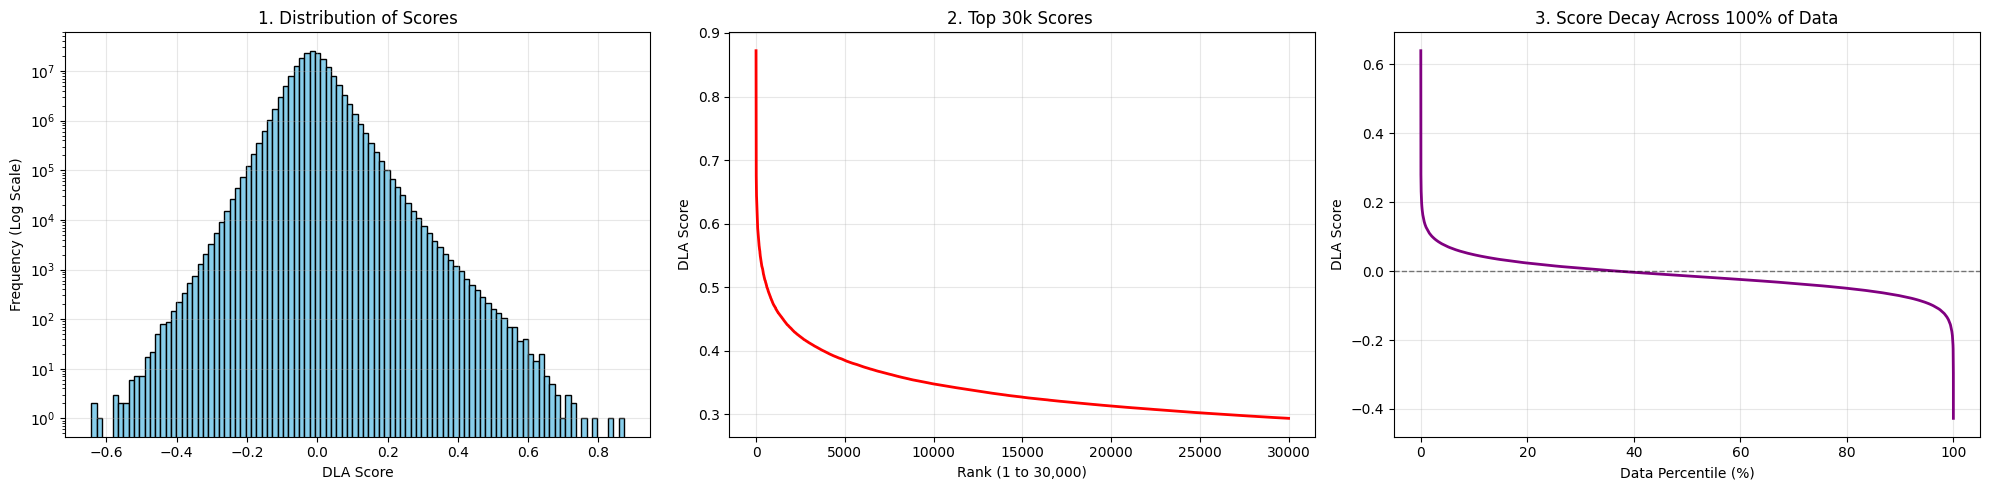

In [19]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. Isolate the head and flatten (175,000,000 scores)
temp = final_tensor[:, -1, :, :].flatten()

# 2. Extract Top 10,000 scores for the micro-view
K = 30000
top_scores, _ = torch.topk(temp, k=K)
top_scores_np = top_scores.detach().cpu().numpy()

# 3. Randomly sample 1 million points for macroscopic views
sample_indices = torch.randint(0, temp.size(0), (1000000,))
sample_dist_np = temp[sample_indices].detach().cpu().numpy()

# 4. Sort the 1M sample descending to approximate the full distribution
sorted_sample = np.sort(sample_dist_np)[::-1]

# 5. Uniformly sample 10,000 points across the entire sorted range
# This creates 10,000 evenly spaced indices from 0 to 1,000,000
uniform_indices = np.linspace(0, len(sorted_sample) - 1, 100000).astype(int)
uniform_scores = sorted_sample[uniform_indices]
# To show true scale, map these indices to percentages (0% to 100% of the data)
percentiles = np.linspace(0, 100, 100000)


# --- Plotting ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5));

# Plot 1: The Log-Scaled Histogram
ax1.hist(temp, bins=100, log=True, color='skyblue', edgecolor='black');
ax1.set_xlabel("DLA Score")
ax1.set_ylabel("Frequency (Log Scale)")
ax1.set_title("1. Distribution of Scores")
ax1.grid(True, alpha=0.3);

# Plot 2: The Rank-Score "Elbow" Plot (Micro-view)
ax2.plot(np.arange(K), top_scores_np, color='red', linewidth=2);
ax2.set_xlabel("Rank (1 to 30,000)")
ax2.set_ylabel("DLA Score")
ax2.set_title("2. Top 30k Scores ")
ax2.grid(True, alpha=0.3);

# Plot 3: The Full Distribution Decay (Macro-view)
ax3.plot(percentiles, uniform_scores, color='purple', linewidth=2);
ax3.set_xlabel("Data Percentile (%)")
ax3.set_ylabel("DLA Score")
ax3.set_title("3. Score Decay Across 100% of Data")
ax3.grid(True, alpha=0.3);

# Optional: Add a horizontal line to Plot 3 showing where zero is
ax3.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5);

plt.tight_layout();
plt.show();

In [40]:
import numpy as np

# Use your 1 million random sample or the full flattened tensor
data =  final_tensor[:, 1, :, :].flatten().detach().cpu().numpy()

median = np.median(data)
mad = np.median(np.abs(data - median))

# K is your strictness multiplier. For heavy tails, 10 to 20 is common.
# If K=15, you are keeping scores that are 15x greater than the average noise.
K = 15 
mad_cutoff = median + (K * mad)

print(f"MAD Cutoff Score: {mad_cutoff}")
print(f"Percentage of scores above cutoff: {(data > mad_cutoff).mean() * 100:.4f}% || number of scores above cutoff: {(data > mad_cutoff).sum()} out of {len(data)}")
print(f"max score: {data.max():.4f}, min score: {data.min():.4f}, median: {median:.4f}, MAD: {mad:.4f}")

MAD Cutoff Score: 0.49725860357284546
Percentage of scores above cutoff: 0.0021% || number of scores above cutoff: 3643 out of 174900000
max score: 1.1186, min score: -0.6294, median: -0.0176, MAD: 0.0343


In [24]:
# # average the 0 and 2 dimensions to get average scores per head per text class
# # final_tensor_averaged = final_tensor.mean(dim=(0, 2))
# # final_tensor_averaged.shape

# sorted_idx = final_tensor_averaged.argsort(dim=1, descending=True)
# # sorted_idx[:,0]

# for i in range(12):
#     for j in range(10):
#         text_idx = sorted_idx[i, j].item()
#         print(f"Head {i} - Text: {texts[text_idx]} - Score: {final_tensor_averaged[i, text_idx].item():.4f}")
#     print("-"*50)

In [38]:
head_idx

[41, 42, 46, 44, 34]

### after rand plots

In [42]:
head_idx

[39, 40, 45, 26, 30]

In [ ]:
for shibu in range(len(head_idx)):
    if head_idx[shibu] != 45:
        continue
    print(f"Analyzing Layer {8+head_idx[shibu]//12} Head {head_idx[shibu]%12}...")    
    temp = torch.clone(final_tensor[:,shibu,:,:])
    gaga = 500
    values, flat_idx = temp.reshape(-1).topk(gaga, largest=False)

    # unravel flat indices to 3D coords
    A, B, C = temp.shape
    i = flat_idx // (B * C)
    j = (flat_idx % (B * C)) // C
    k = flat_idx % C
    indices = torch.stack([i, j, k], dim=1)


    top_names = []
    avg_vals = {}
    for i in range(gaga):
        top_names.append(texts[indices[i][2].item()])
        avg_vals[texts[indices[i][2].item()]] = avg_vals.get(texts[indices[i][2].item()], []) + [values[i].item()]

    #sort avg_vals by mean value
    # avg_vals = {k: sum(v)/len(v) for k, v in avg_vals.items()}
    # avg_vals = dict(sorted(avg_vals.items(), key=lambda item: item[1], reverse=True))


    from collections import Counter
    name_counts = Counter(top_names)
    # print(name_counts.most_common(20))
    # print(list(avg_vals.items())[:20])
    for name, count in name_counts.most_common(20):
        print(f"{name}: {count} : {sum(avg_vals[name])/len(avg_vals[name]):.3f}", end="||")
        print(f"{name}: {count} : {sum(avg_vals[name])/len(avg_vals[name]):.3f}")
    print("\n" + "-"*50)

Analyzing Layer 11 Head 9...
An image of the number 7: 32 : 0.748||An image of the number 2: 30 : 0.757||The number two: 28 : 0.733||An image of the number 10: 27 : 0.823||The number fifteen: 27 : 0.749||An image of the number 5: 22 : 0.820||The number six: 20 : 0.739||The number twelve: 19 : 0.810||An image of the number 8: 19 : 0.749||Image with a four people: 19 : 0.758||The number five: 18 : 0.820||An image of the number 4: 18 : 0.729||The number seven: 17 : 0.742||An image of the number 3: 15 : 0.741||An image of the number 6: 15 : 0.731||Image with a five people: 13 : 0.881||Close-up of a textured leather: 12 : 0.725||Image with a seven people: 12 : 0.704||Image with five subjects: 11 : 0.795||The number three: 11 : 0.719||
--------------------------------------------------


In [95]:
# name_counts

In [40]:
for i in range(100):
    img_class_idx, image_idx, class_idx = indices[i]
    img_class_name = idx_to_name[img_class_idx.item()]
    logit_class_name = texts[class_idx.item()]
    print(f"Image Class: {img_class_name} | Logit Class: {logit_class_name}  | img_idx: {image_idx.item()} | DLA: {values[i].item():.3f}")

Image Class: honeycomb | Logit Class: Honeycomb design  | img_idx: 31 | DLA: 1.012
Image Class: honeycomb | Logit Class: A honeycomb pattern  | img_idx: 31 | DLA: 1.007
Image Class: water_bottle | Logit Class: Honeycomb design  | img_idx: 0 | DLA: 1.005
Image Class: space_bar | Logit Class: Snapshot of a marsupial  | img_idx: 24 | DLA: 0.985
Image Class: water_bottle | Logit Class: A honeycomb pattern  | img_idx: 0 | DLA: 0.973
Image Class: matchstick | Logit Class: A honeycomb pattern  | img_idx: 17 | DLA: 0.967
Image Class: matchstick | Logit Class: Honeycomb design  | img_idx: 17 | DLA: 0.943
Image Class: honeycomb | Logit Class: Image with honeycomb patterns  | img_idx: 31 | DLA: 0.932
Image Class: honeycomb | Logit Class: Honeycomb design  | img_idx: 33 | DLA: 0.929
Image Class: honeycomb | Logit Class: Honeycomb design  | img_idx: 40 | DLA: 0.927
Image Class: coil | Logit Class: Image with spiral patterns  | img_idx: 34 | DLA: 0.916
Image Class: water_bottle | Logit Class: Image 

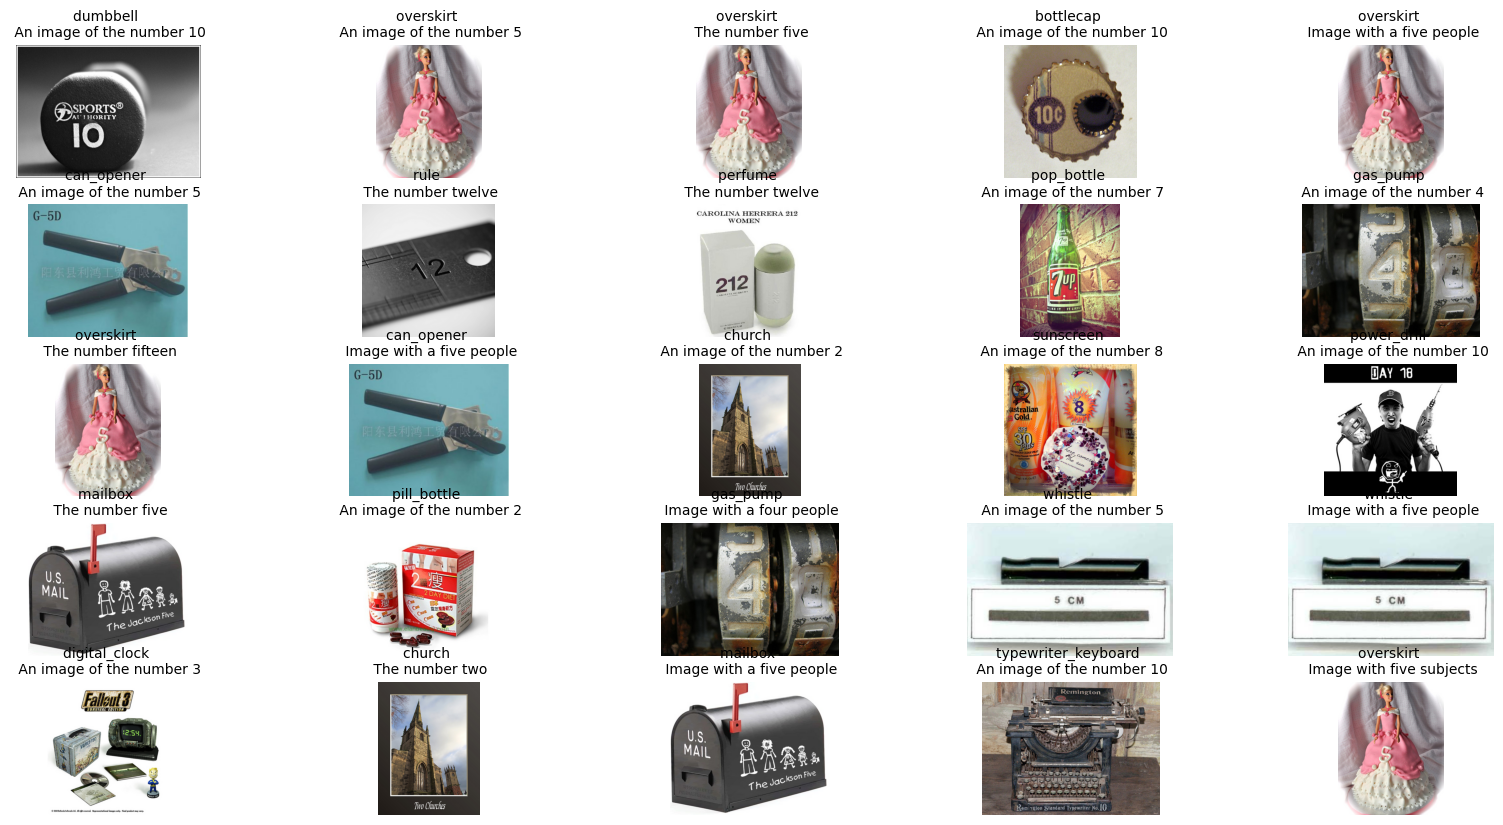

In [35]:
fig, axes = plt.subplots(5, 5, figsize=(20, 10))

xx = 25*0
for i in range(xx, xx+25):
    img_class_idx, image_idx, class_idx = indices[i]
    name = idx_to_name[img_class_idx.item()]
    idx = name_to_idx[name]
    id = idx_to_wnid[idx]
    img_idx = image_idx.item()

    dataset_idx = idx*50 + img_idx
    # dataset_idx
    # filder dataset by class id, dataset.classes used the wind
    # dataset[dataset_idx][0]
    j = i%25
    img = dataset[dataset_idx][0]
    ax = axes[j//5, j%5]
    ax.imshow(img)
    ax.set_title(f"{name} \n {texts[class_idx.item()]}", fontsize=10)
    ax.axis('off')

In [116]:
## patch level attribution

myidx = 21+xx
img_class_idx, image_idx, class_idx = indices[myidx]
name = idx_to_name[img_class_idx.item()]
idx = name_to_idx[name]
id = idx_to_wnid[idx]
img_idx = image_idx.item()

dataset_idx = idx*50 + img_idx
# dataset_idx
# filder dataset by class id, dataset.classes used the wind
# dataset[dataset_idx][0]
img = dataset[dataset_idx][0]
img_processed = transform(img).unsqueeze(0).to(model.cfg.device)
final_output, cache = model.run_with_cache(img_processed)

all_head_residuals = cache.stack_head_results(layer=-1, pos_slice=0)

scaled_head_residuals = cache.apply_ln_to_stack(
    all_head_residuals, layer=-1, pos_slice=0
)

# Slice to keep only the last 4 layers (last 48 indices on the 0th dimension)
# Shape becomes: [48, 50, 768]
last_4_layers_residual = scaled_head_residuals[-48:, :, :]


raw_dla = torch.einsum(
    "b d, c d -> b c",  # h=heads, b=batch, d=d_model, c=classes
    last_4_layers_residual[-2],
    target_direction,
)

# target_score = raw_dla[0, class_idx]
# top 5 texts for this image
topk = 15
values, text_indices = raw_dla.topk(topk, dim=-1, largest=True)
for i in range(topk):
    print(f"Text: {texts[text_indices[0, i].item()]} - Score: {values[0, i].item():.4f}")

Tried to stack head results when they weren't cached. Computing head results now
Text: Image with a blue color - Score: 2.4389
Text: Photograph with a blue color palette - Score: 2.1449
Text: Photo with vibrant, saturated colors - Score: 0.7678
Text: Vibrant colors - Score: 0.6716
Text: Playful hues - Score: 0.6492
Text: Playful colors - Score: 0.6447
Text: Image with a purple color - Score: 0.6358
Text: Enchanting starry night sky - Score: 0.6141
Text: Photo with vibrant, contrasting colors - Score: 0.6097
Text: Burst of color - Score: 0.6053
Text: Evolving colors - Score: 0.6011
Text: Pop art colors - Score: 0.5929
Text: magical twilight sky - Score: 0.5910
Text: colorful underwater world - Score: 0.5902
Text: colorful event - Score: 0.5873


In [23]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math

2026-05-13 08:53:15 DEBUG:matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x704d18794e80>


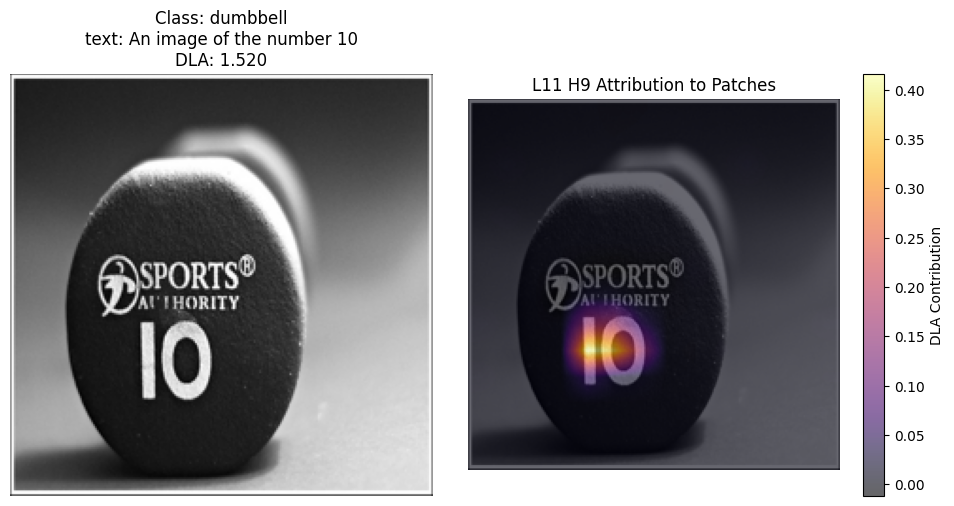

In [37]:
myidx = xx+0
img_class_idx, image_idx, class_idx = indices[myidx]
class_idx = class_idx.item()
name = idx_to_name[img_class_idx.item()]
idx = name_to_idx[name]
id = idx_to_wnid[idx]
img_idx = image_idx.item()
dataset_idx = idx*50 + img_idx
img = dataset[dataset_idx][0]
img_processed = transform(img).unsqueeze(0).to(model.cfg.device)
final_output, cache = model.run_with_cache(img_processed)

target_layer = 11  # e.g., Layer 11
target_head = 9   # e.g., Head 10 (The Color Head)


attn_weights = cache[f"blocks.{target_layer}.attn.hook_pattern"][0, target_head, 0, 1:]
v_patches = cache[f"blocks.{target_layer}.attn.hook_v"][0, 1:, target_head, :]
W_O = model.blocks[target_layer].attn.W_O[target_head, :, :]
unweighted_payloads = v_patches @ W_O
weighted_contributions = unweighted_payloads * attn_weights.unsqueeze(-1)
ln_scale = cache["ln_final.hook_scale"][0, 0, :]  # Scale at CLS token position
scaled_contributions = weighted_contributions / ln_scale
patch_dla = scaled_contributions @ target_direction[class_idx]
num_patches = patch_dla.shape[0]
grid_size = int(math.sqrt(num_patches))
patch_heatmap = patch_dla.reshape(grid_size, grid_size).detach().cpu()


img_display = np.array(img.resize((224, 224)))  # Resize to match the heatmap if needed
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_display)
plt.title(f"Class: {name}\ntext: {texts[class_idx]}\nDLA: {patch_dla.sum().item():.3f}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_display)

heatmap_resized = F.interpolate(
    patch_heatmap.unsqueeze(0).unsqueeze(0), 
    size=(img_display.shape[0], img_display.shape[1]), 
    mode='bilinear', 
    align_corners=False
).squeeze().numpy()

plt.imshow(heatmap_resized, cmap='inferno', alpha=0.6)
#add colorbar
plt.colorbar(label='DLA Contribution')
plt.title(f"L{target_layer} H{target_head} Attribution to Patches")
plt.axis('off')

plt.tight_layout()
plt.show()

2026-05-13 08:53:46 DEBUG:matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x704d185988e0>


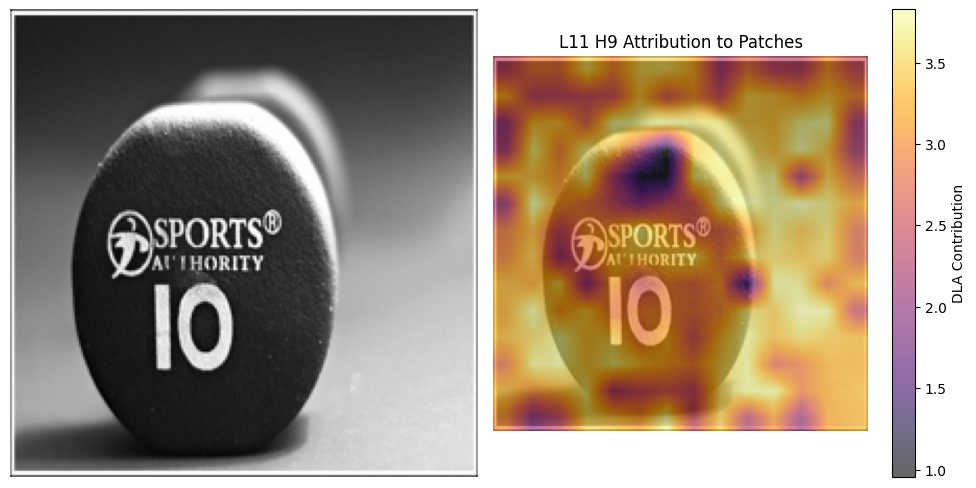

In [39]:
import torch.nn.functional as F
import math

myidx = 0
img_class_idx, image_idx, class_idx = indices[myidx]
class_idx = class_idx.item()
name = idx_to_name[img_class_idx.item()]
idx = name_to_idx[name]
id = idx_to_wnid[idx]
img_idx = image_idx.item()
dataset_idx = idx*50 + img_idx
img = dataset[dataset_idx][0]
img_processed = transform(img).unsqueeze(0).to(model.cfg.device)
final_output, cache = model.run_with_cache(img_processed)

target_layer = 11  # e.g., Layer 11
target_head = 9   # e.g., Head 10 (The Color Head)

# ── inputs you already have ──────────────────────────────────────────
# target_text = "An image of the number 7"   # whatever text you want to probe
target_text = texts[class_idx]  # the text corresponding to the true class of this image
text_emb = text_dict[texts.index(target_text)]  # [512], already normalized

# ── get patch residual stream after the last block ───────────────────
# resid_post = cache[f"blocks.{model.cfg.n_layers-1}.hook_resid_post"][0, 1:, :]
# # shape: [num_patches, 768], slicing off CLS (position 0)

# # ── apply final layer norm ───────────────────────────────────────────
# with torch.no_grad():
#     ln_patches = model.ln_final(resid_post)           # [num_patches, 768]

# # ── project to CLIP joint space ──────────────────────────────────────
# patch_clip = ln_patches @ proj_head                   # [num_patches, 512]

# # ── direct attribution score per patch ──────────────────────────────
# patch_scores = patch_clip @ text_emb                  # [num_patches]

# # ── reshape to spatial grid and visualize ───────────────────────────
# num_patches = patch_scores.shape[0]
# grid_size = int(math.sqrt(num_patches))
# patch_heatmap = patch_scores.reshape(grid_size, grid_size).detach().cpu()

# ── head output at each patch position ──────────────────────────────
attn_all = cache[f"blocks.{target_layer}.attn.hook_pattern"][0, target_head]  
# [seq_len, seq_len]

v_all = cache[f"blocks.{target_layer}.attn.hook_v"][0, :, target_head, :]    
# [seq_len, head_dim]

W_O = model.blocks[target_layer].attn.W_O[target_head, :, :]                 
# [head_dim, 768]

# for each patch position j: sum_i attn[j,i] * v[i] @ W_O
attn_patches = attn_all[1:, :]        # [num_patches, seq_len], attention FROM each patch
head_out = attn_patches @ v_all @ W_O # [num_patches, 768]

# ── project to CLIP space ────────────────────────────────────────────
with torch.no_grad():
    ln_head_out = model.ln_final(head_out)    # [num_patches, 768]

patch_clip   = ln_head_out @ proj_head        # [num_patches, 512]
patch_scores = patch_clip @ text_emb          # [num_patches]

# ── reshape ──────────────────────────────────────────────────────────
grid_size    = int(math.sqrt(patch_scores.shape[0]))
patch_heatmap = patch_scores.reshape(grid_size, grid_size).detach().cpu()

img_display = np.array(img.resize((224, 224)))  # Resize to match the heatmap if needed
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_display)
# plt.title(f"Class: {name}\ntext: {texts[class_idx]}\nDLA: {patch_dla.sum().item():.3f}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_display)

heatmap_resized = F.interpolate(
    patch_heatmap.unsqueeze(0).unsqueeze(0), 
    size=(img_display.shape[0], img_display.shape[1]), 
    mode='bilinear', 
    align_corners=False
).squeeze().numpy()

plt.imshow(heatmap_resized, cmap='inferno', alpha=0.6)
#add colorbar
plt.colorbar(label='DLA Contribution')
plt.title(f"L{target_layer} H{target_head} Attribution to Patches")
plt.axis('off')

plt.tight_layout()
plt.show()

In [29]:
# target_direction.shape, cache['blocks.11.hook_resid_post'][:, 0, :].shape, last_4_layers_residual[-1].shape
# last_4_layers_residual.shape
# raw_dla[:,:10]
max_indices = raw_dla.argmax(dim=-1)
topk = 5
topk_indices = torch.topk(raw_dla, k=topk, dim=-1).indices.squeeze()
print(f"Top {topk} most similar prompts:")
for idx in topk_indices:
    print(f"{texts[idx]} (similarity: {raw_dla[0, idx].item():.4f})")

Top 5 most similar prompts:
A photo with the letter H (similarity: 1.5979)
A helix (similarity: 0.8128)
A photo with the letter I (similarity: 0.7618)
A heptagon (similarity: 0.7490)
Harmonious coexistence (similarity: 0.7391)
